# Predicción del precio de alojamientos de Airbnb en Río de Janeiro

**Aprendizaje de Máquina - CEIA - FIUBA**

*Trabajo Práctico Final*

---

# 1. Introducción al problema

## 1.1. Contexto

[Inside Airbnb](https://insideairbnb.com/) publica relevamientos periódicos de los avisos de Airbnb como
datos abiertos. Usamos el relevamiento de Río de Janeiro del 30 de marzo de 2026, versión detallada
(`listings.csv.gz`, 90 columnas). Fuente: https://insideairbnb.com/rio-de-janeiro/ (el archivo comprimido
está en esta misma carpeta).

## 1.2. El problema

Predecir el precio por noche (`price`, en BRL) de un alojamiento a partir de sus atributos publicados:
ubicación, tamaño, tipo y comodidades. Es un problema de regresión supervisada, con cada aviso como
unidad de observación.

## 1.3. Qué esperamos encontrar

Esperamos que tamaño y ubicación expliquen buena parte del precio, con un techo dado por decisiones
subjetivas del anfitrión que ningún atributo captura. La geografía de Río no es lineal (barrios caros y
baratos se alternan en pocos kilómetros), así que anticipamos ventaja para los modelos basados en
árboles. Antes de entrenar nada armamos un baseline heurístico (precio típico por barrio y tipo de
habitación) para saber cuánto aporta cada modelo por encima de eso.

## 1.4. Antecedente

En Análisis de Datos hicimos un EDA sobre un dataset similar de Inside Airbnb, pero `price` venía 100 %
nula. Terminamos prediciendo la cantidad de reseñas, con señal pobre. Este trabajo retoma esa línea con
el dato que faltaba.

---

# 2. Datos: descripción y preparación

In [2]:
import json
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import urllib.request

warnings.filterwarnings("ignore")
sns.set()

# Paleta de la cátedra
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"
BASELINE = "#aaaaaa"

SEMILLA = 42

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")
# Filtro específico: sklearn.utils.parallel emite un UserWarning informativo
# cada vez que `cross_val_predict` se usa con n_jobs=-1 fuera de un
# `Parallel(...)` propio — es ruido interno de sklearn >=1.5, no afecta
# correctness. Se imprime ~95 veces en el barrido de max_features de RF.


## 2.1. Carga y primer vistazo

In [3]:
# --- 2.1. Carga del dataset ---
urllib.request.urlretrieve("https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/data/listings.csv.gz", "./airbnb-listings-rj.csv.gz")
df = pd.read_csv("./airbnb-listings-rj.csv.gz", low_memory=False)

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    48,713
Columnas: 90


In [4]:
# --- OPCIONAL: subsample para una corrida de verificación rápida ---
# Descomentar las dos líneas de abajo para correr todo el cuaderno sobre
# una muestra chica (cambia también el tamaño del test, así que los
# números son sólo para validar que el código cierra sin errores). Para
# la entrega, dejar comentadas.
df = df.sample(n=1000, random_state=SEMILLA).reset_index(drop=True)

In [5]:
# Resumen de tipos y faltantes, ordenado por porcentaje de nulos
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().mean() * 100).round(1),
}).sort_values("%_nulos", ascending=False)

resumen.head(20)

,dtype,nulos,%_nulos
neighborhood_overview,float64,1000,100.0
host_since,float64,1000,100.0
host_response_time,float64,1000,100.0
host_thumbnail_url,float64,1000,100.0
host_acceptance_rate,float64,1000,100.0
host_response_rate,float64,1000,100.0
host_verifications,float64,1000,100.0
neighbourhood,float64,1000,100.0
host_total_listings_count,float64,1000,100.0
host_neighbourhood,float64,1000,100.0


## 2.2. Auditoría de fuga de información

El dataset trae columnas derivadas del propio precio. Si alguna entra como feature, el modelo no aprende
a predecir: copia la respuesta. Lo verificamos numéricamente.

In [6]:
# --- 2.2. Auditoría de fuga ---
# El precio viene como texto (ej."$565.00"): lo pasamos a número para poder comparar.
precio_raw = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
con_precio = precio_raw.notna()
n = int(con_precio.sum())

print(f"Listings con precio informado: {n:,} de {len(df):,} "
     f"({100 * con_precio.mean():.1f} %)\n")

# Hipótesis 1: price_quote_price_per_night es el mismo número que price
iguales = np.isclose(precio_raw[con_precio],
                     df.loc[con_precio, "price_quote_price_per_night"])
print(f"price == price_quote_price_per_night : {iguales.sum():,}/{n:,} "
      f"({100 * iguales.mean():.2f} %)")

# Hipótesis 2: estimated_revenue_l365d = price x estimated_occupancy_l365d
reconstruido = precio_raw[con_precio] * df.loc[con_precio, "estimated_occupancy_l365d"]
iguales_rev = np.isclose(df.loc[con_precio, "estimated_revenue_l365d"], reconstruido, rtol=0.01)
print(f"estimated_revenue == price x ocupación: {iguales_rev.sum():,}/{n:,} "
      f"({100 * iguales_rev.mean():.2f} %)")

Listings con precio informado: 921 de 1,000 (92.1 %)

price == price_quote_price_per_night : 921/921 (100.00 %)
estimated_revenue == price x ocupación: 921/921 (100.00 %)


Las dos hipótesis se confirman: `estimated_revenue_l365d` es exactamente precio × ocupación en todas las
filas, y dejarla como feature le entrega la respuesta al modelo. Columnas a eliminar:

In [7]:
# --- Política de fuga: estas columnas NO pueden entrar al modelo ---
COLS_FUGA = [
    "price_quote_price_per_night",   # idéntica al target
    "price_quote_total_price",       # precio x noches de la cotización
    "price_quote_raw",               # texto crudo, contiene el precio
    "estimated_revenue_l365d",       # = price x estimated_occupancy_l365d
    "price_quote_checkin_date",      # metadata de la cotización
    "price_quote_checkout_date",
]

df = df.drop(columns=COLS_FUGA, errors="ignore")

print("Columnas excluidas por fuga de información:")
for c in COLS_FUGA:
    print(f"  - {c}")

print("Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es "
      "información legítima sobre la demanda del alojamiento.")

Columnas excluidas por fuga de información:
  - price_quote_price_per_night
  - price_quote_total_price
  - price_quote_raw
  - estimated_revenue_l365d
  - price_quote_checkin_date
  - price_quote_checkout_date
Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es información legítima sobre la demanda del alojamiento.


## 2.3. Columnas sin información

Quedan columnas que sobreviven en el encabezado pero vienen completamente vacías en este relevamiento.
Las damos de baja.

In [8]:
# --- 2.3. Columnas 100 % nulas ---
# Se recalcula sobre df (y no sobre `resumen`) para que la celda sea
# idempotente aunque ya se hayan eliminado columnas.
nulos_pct = df.isnull().mean() * 100
cols_vacias = nulos_pct.index[nulos_pct == 100].tolist()

print(f"Columnas con 100 % de valores faltantes: {len(cols_vacias)}\n")
for c in cols_vacias:
    print(f"  - {c}")

df = df.drop(columns=cols_vacias, errors="ignore")

Columnas con 100 % de valores faltantes: 14

  - neighborhood_overview
  - host_since
  - host_response_time
  - host_response_rate
  - host_acceptance_rate
  - host_thumbnail_url
  - host_neighbourhood
  - host_total_listings_count
  - host_verifications
  - neighbourhood
  - neighbourhood_group_cleansed
  - calendar_updated
  - license
  - instant_bookable


## 2.4. La variable objetivo

`price` viene como texto con símbolo de moneda: lo convertimos a número. Las filas sin precio se
descartan, porque el target no se imputa.

In [9]:
# --- 2.4. Parseo del target ---
print("Formato original:", df["price"].dropna().head(3).tolist())

# Se recalcula desde df["price"] en vez de reusar `precio_raw`: asignar una
# Serie externa alinea por índice, y tras el reset_index de más abajo esta
# celda dejaría de ser idempotente (mezclaría precios entre listings).
df["precio"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

filas_antes = len(df)
df = df.dropna(subset=["precio"]).reset_index(drop=True)

print("Formato parseado:", df["precio"].head(3).tolist())
print(f"\nFilas descartadas por no tener precio: {filas_antes - len(df):,} "
      f"({100 * (filas_antes - len(df)) / filas_antes:.1f} %)")
print(f"Filas restantes: {len(df):,}")

Formato original: ['$307.00', '$973.50', '$1,141.20']
Formato parseado: [307.0, 973.5, 1141.2]

Filas descartadas por no tener precio: 79 (7.9 %)
Filas restantes: 921


In [10]:
df["precio"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(1)

count      921.0
mean       831.1
std       1825.1
min         24.0
1%          95.4
25%        291.0
50%        455.0
75%        799.0
95%       2205.0
99%       6140.3
max      28530.0
Name: precio, dtype: float64

Encontramos un problema: la mediana está en **500 BRL** pero el máximo llega a **570.726 BRL**,
más de mil veces la mediana. La media (890) supera ampliamente a la mediana, señal de una cola
derecha muy pesada.

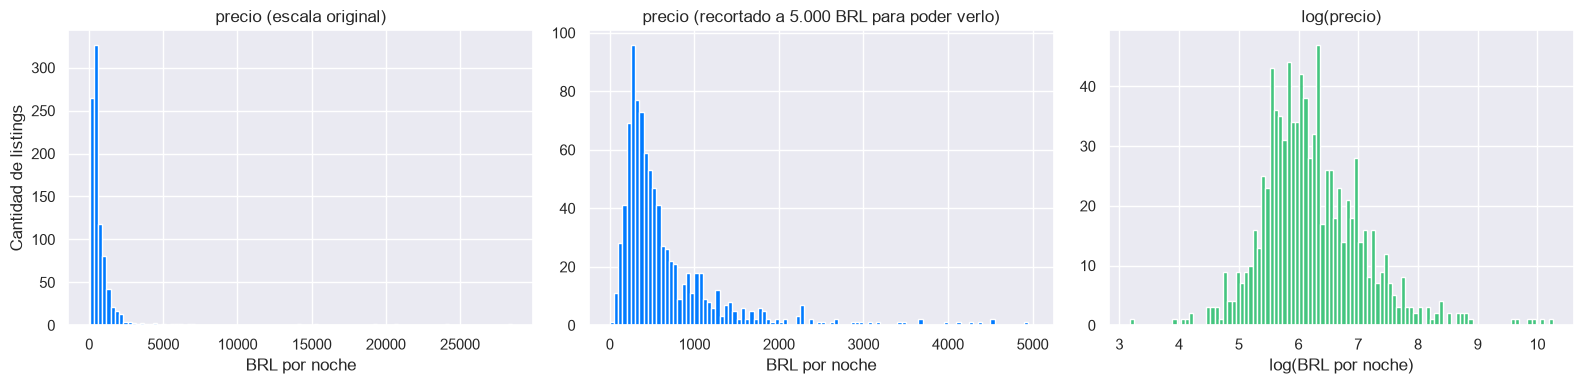

Asimetría (skew) de precio      :    9.967
Asimetría (skew) de log(precio) :    0.859
Kurtosis (peso de la cola del dataset) de precio              :  120.344
Kurtosis (peso de la cola del dataset) de log(precio)         :    2.320


In [11]:
# --- Distribución del target en escala original y logarítmica ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["precio"], bins=100, color=AZUL, edgecolor="white")
axes[0].set_title("precio (escala original)")
axes[0].set_xlabel("BRL por noche")
axes[0].set_ylabel("Cantidad de listings")

axes[1].hist(df["precio"], bins=100, range=(0, 5000), color=AZUL, edgecolor="white")
axes[1].set_title("precio (recortado a 5.000 BRL para poder verlo)")
axes[1].set_xlabel("BRL por noche")

axes[2].hist(np.log(df["precio"]), bins=100, color=VERDE, edgecolor="white")
axes[2].set_title("log(precio)")
axes[2].set_xlabel("log(BRL por noche)")

plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de precio      : {df['precio'].skew():8.3f}")
print(f"Asimetría (skew) de log(precio) : {np.log(df['precio']).skew():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de precio              : {df['precio'].kurtosis():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de log(precio)         : {np.log(df['precio']).kurtosis():8.3f}")

El primer histograma es ilegible: los valores extremos estiran la escala. El tercero, en cambio, es
aproximadamente normal.

Antes de recortar el rango de `price` queremos entender esos valores extremos. Hay dos explicaciones: Río
tiene lujo real (mansiones en Joá o São Conrado a miles de dólares la noche) y también precios mal
cargados (valor mensual puesto en el campo diario, o números absurdos para bloquear el calendario). Las
distinguimos con un criterio de mercado: un precio es real si alguien lo pagó. Si el alojamiento nunca
tuvo una reseña y su ocupación estimada es casi nula, ese precio nunca fue validado.

In [12]:
# --- 2.5. Anatomía de la cola alta ---
franjas = pd.cut(
    df["precio"],
    bins=[0, 1000, 2000, 5000, 10000, np.inf],
    labels=["< 1.000", "1.000 - 2.000", "2.000 - 5.000", "5.000 - 10.000", "> 10.000"],
)

tabla = pd.DataFrame({
    "listings": df.groupby(franjas, observed=True)["precio"].size(),
    "% sin reseñas": df.groupby(franjas, observed=True)["number_of_reviews"].apply(
        lambda s: 100 * (s == 0).mean()),
    "ocupación media (días/año)": df.groupby(franjas, observed=True)["estimated_occupancy_l365d"].mean(),
    "precio/persona (mediana)": df.groupby(franjas, observed=True).apply(
        lambda g: (g["precio"] / g["accommodates"]).median(), include_groups=False),
})

tabla.round(1)

,listings,% sin reseñas,ocupación media (días/año),precio/persona (mediana)
precio,,,,
< 1.000,744,14.1,62.6,121.9
1.000 - 2.000,127,34.6,33.2,274.0
2.000 - 5.000,36,52.8,16.8,553.3
5.000 - 10.000,8,12.5,21.8,1195.3
> 10.000,6,50.0,10.0,3242.3


El patrón es marcado: cuanto más caro el aviso, más probable que nunca se haya alquilado. Por debajo de
1.000 BRL, el 14 % no tiene reseñas y la ocupación media es 65 días al año; por encima de 10.000 BRL, dos
de cada tres no tienen ninguna reseña y la ocupación cae a menos de 9 días.

Los casos extremos:

In [13]:
# Los 8 precios más altos del dataset
df.nlargest(8, "precio")[[
    "precio", "accommodates", "bedrooms", "room_type",
    "neighbourhood_cleansed", "number_of_reviews", "estimated_occupancy_l365d",
]]

,precio,accommodates,bedrooms,room_type,neighbourhood_cleansed,number_of_reviews,estimated_occupancy_l365d
138,28530.00,6,3.0,Entire home/apt,Copacabana,0,0
872,24231.92,4,2.0,Entire home/apt,Botafogo,2,0
905,20756.00,12,6.0,Entire home/apt,Santa Teresa,0,0
431,19383.88,4,1.0,Entire home/apt,Centro,1,60
321,15406.00,10,4.0,Entire home/apt,Joá,0,0
278,14265.00,9,5.0,Entire home/apt,Joá,11,0
829,7099.95,15,6.0,Entire home/apt,Barra da Tijuca,1,6
95,6867.00,2,NaN,Private room,Santa Teresa,182,48


El máximo es un dos ambientes para cuatro personas en Estácio (barrio no premium) a 570.726 BRL, unos
USD 105.000, con una sola reseña: no es lujo, es un dato mal cargado. Más abajo en la lista sí aparecen
casas grandes en barrios caros, con capacidad para catorce personas, plausibles.

Decisión: descartamos los alojamientos con precio superior a 10.000 BRL por noche. Es un corte
conservador, justificado por la tabla anterior y no por un percentil arbitrario, asumiendo la pérdida de
algún lujo genuino.

In [14]:
# --- Aplicación del corte ---
CORTE = 10_000

fuera = (df["precio"] > CORTE).sum()
print(f"Listings descartados por precio > {CORTE:,} BRL: {fuera:,} "
      f"({100 * fuera / len(df):.2f} %)")

df = df[df["precio"] <= CORTE].reset_index(drop=True)
df["precio_log"] = np.log(df["precio"])

print(f"Listings restantes: {len(df):,}")
print(f"\nNuevo rango de precios: {df['precio'].min():.0f} - {df['precio'].max():.0f} BRL")
print(f"Asimetría tras el corte : {df['precio'].skew():.3f}  "
      f"(log: {df['precio_log'].skew():.3f})")

Listings descartados por precio > 10,000 BRL: 6 (0.65 %)
Listings restantes: 915

Nuevo rango de precios: 24 - 7100 BRL
Asimetría tras el corte : 4.078  (log: 0.459)


## 2.6. Valores faltantes

Qué falta en lo que queda, ya sin las columnas vacías.

In [15]:
# --- 2.6. Faltantes restantes ---
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

pd.DataFrame({
    "nulos": faltantes,
    "%": (100 * faltantes / len(df)).round(1),
})

,nulos,%
host_about,458,50.1
host_location,199,21.7
review_scores_value,169,18.5
last_review,169,18.5
first_review,169,18.5
review_scores_communication,169,18.5
review_scores_checkin,169,18.5
review_scores_cleanliness,169,18.5
review_scores_accuracy,169,18.5
review_scores_rating,169,18.5


El 17 % de faltantes en reseñas podría ser estructural: un alojamiento sin reseñas tampoco puede tener
puntaje ni fecha de primera reseña. Lo verificamos.

In [16]:
# --- ¿Los faltantes de reseñas son estructurales? ---
sin_reseñas = df["number_of_reviews"] == 0

print(f"Listings con 0 reseñas: {sin_reseñas.sum():,} "
      f"({100 * sin_reseñas.mean():.1f} %)\n")

for col in ["reviews_per_month", "review_scores_rating", "first_review", "last_review"]:
    nulo = df[col].isna()
    coincidencia = (nulo == sin_reseñas).mean() * 100
    print(f"{col:24s} nulos = {nulo.sum():6,}   "
          f"coincide con 'sin reseñas': {coincidencia:6.2f} %")

Listings con 0 reseñas: 169 (18.5 %)

reviews_per_month        nulos =    169   coincide con 'sin reseñas': 100.00 %
review_scores_rating     nulos =    169   coincide con 'sin reseñas': 100.00 %
first_review             nulos =    169   coincide con 'sin reseñas': 100.00 %
last_review              nulos =    169   coincide con 'sin reseñas': 100.00 %


Los faltantes de reseñas están completamente explicados por una variable observada, así que el mecanismo
es MAR en el sentido estricto. Por lo tanto podemos proceder a crear una variable binaria que capture el
hecho y rellenar con un valor neutro que el modelo pueda asociar a esa bandera.

## 2.7. Precio y variables categóricas

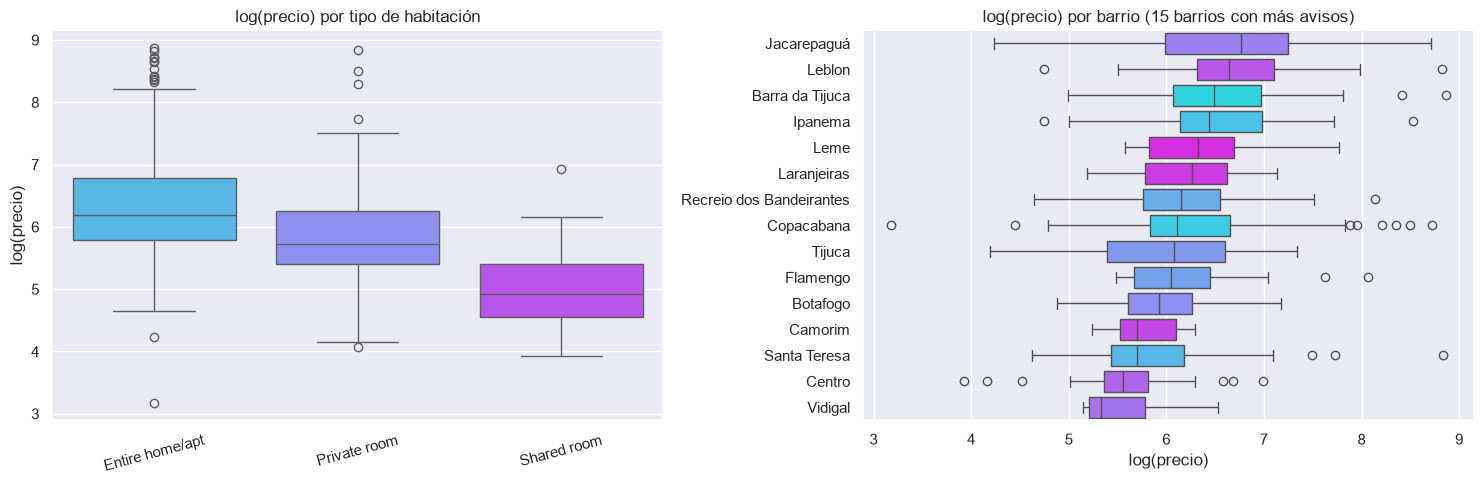

,listings,mediana,media,% del total
room_type,,,,
Entire home/apt,736,488.0,754.0,80.4
Private room,164,308.2,515.2,17.9
Shared room,15,137.0,226.4,1.6


In [17]:
# --- 2.7. Precio por tipo de habitación ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df.groupby("room_type", observed=True)["precio_log"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="precio_log", order=orden,
            hue="room_type", legend=False, palette="cool", ax=axes[0])
axes[0].set_title("log(precio) por tipo de habitación")
axes[0].set_xlabel("")
axes[0].set_ylabel("log(precio)")
axes[0].tick_params(axis="x", rotation=15)

top_barrios = df["neighbourhood_cleansed"].value_counts().head(15).index
sub = df[df["neighbourhood_cleansed"].isin(top_barrios)]
orden_b = sub.groupby("neighbourhood_cleansed", observed=True)["precio_log"].median().sort_values(ascending=False).index
sns.boxplot(data=sub, y="neighbourhood_cleansed", x="precio_log", order=orden_b,
            hue="neighbourhood_cleansed", legend=False, palette="cool", ax=axes[1])
axes[1].set_title("log(precio) por barrio (15 barrios con más avisos)")
axes[1].set_ylabel("")
axes[1].set_xlabel("log(precio)")

plt.tight_layout()
plt.show()

resumen_cat = df.groupby("room_type", observed=True)["precio"].agg(
    listings="size", mediana="median", media="mean").sort_values("mediana", ascending=False)
resumen_cat["% del total"] = (100 * resumen_cat["listings"] / len(df)).round(1)
resumen_cat.round(1)

La variable `room_type` separa con claridad: un alojamiento entero vale casi el doble que una habitación
privada, y una compartida menos de un tercio. Está muy desbalanceada (82 % enteros, apenas 13 casos de
`Hotel room`).

Los barrios muestran el otro eje: Leblon, Ipanema y Barra da Tijuca encabezan la lista, todos en la zona
sur costera. Entre Leblon (893 BRL) y Tijuca (269 BRL) hay un factor de 3,3, considerando barrios con al
menos 200 avisos.

## 2.8. Precio y variables numéricas

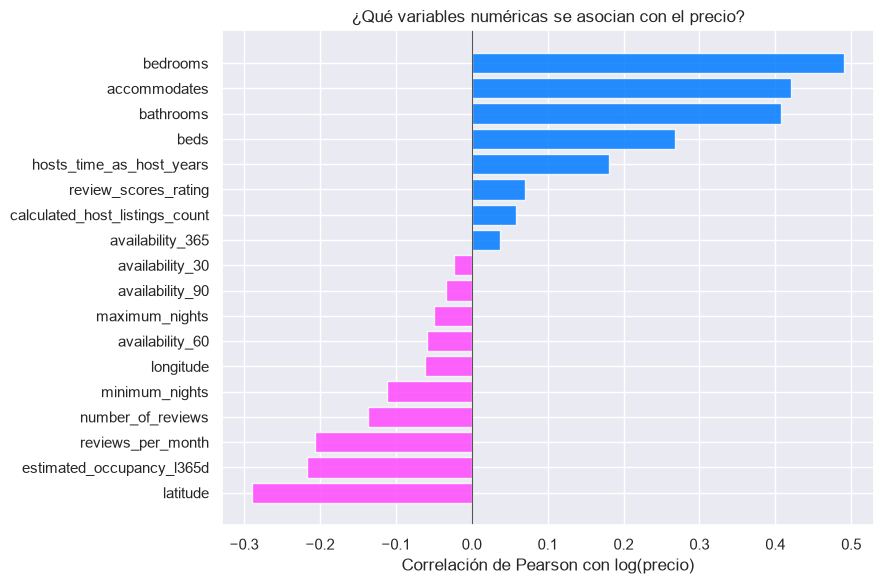

In [18]:
# --- 2.8. Correlación de cada variable numérica con el target ---
NUMERICAS = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "availability_30", "availability_60", "availability_90", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "hosts_time_as_host_years", "latitude", "longitude",
]

corr_target = df[NUMERICAS + ["precio_log"]].corr()["precio_log"].drop("precio_log").sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colores = [AZUL if v > 0 else MAGENTA for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores, alpha=0.85)
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con log(precio)")
ax.set_title("¿Qué variables numéricas se asocian con el precio?")
plt.tight_layout()
plt.show()

El tamaño manda: `bedrooms` (+0,49), `accommodates` (+0,46) y `bathrooms` (+0,44) son las correlaciones
más fuertes.

Más interesante es la geografía: `latitude` da −0,31 pero `longitude` apenas +0,03. La zona sur costera
(Leblon, Ipanema, Copacabana) es cara, pero al oeste Barra da Tijuca también lo es y al este el Centro es
barato — una recta no captura eso. La geografía de Río es no lineal, primer indicio a favor de árboles.

Reseñas y ocupación correlacionan negativo y débil, coherente con la cola alta: lo caro se alquila menos.

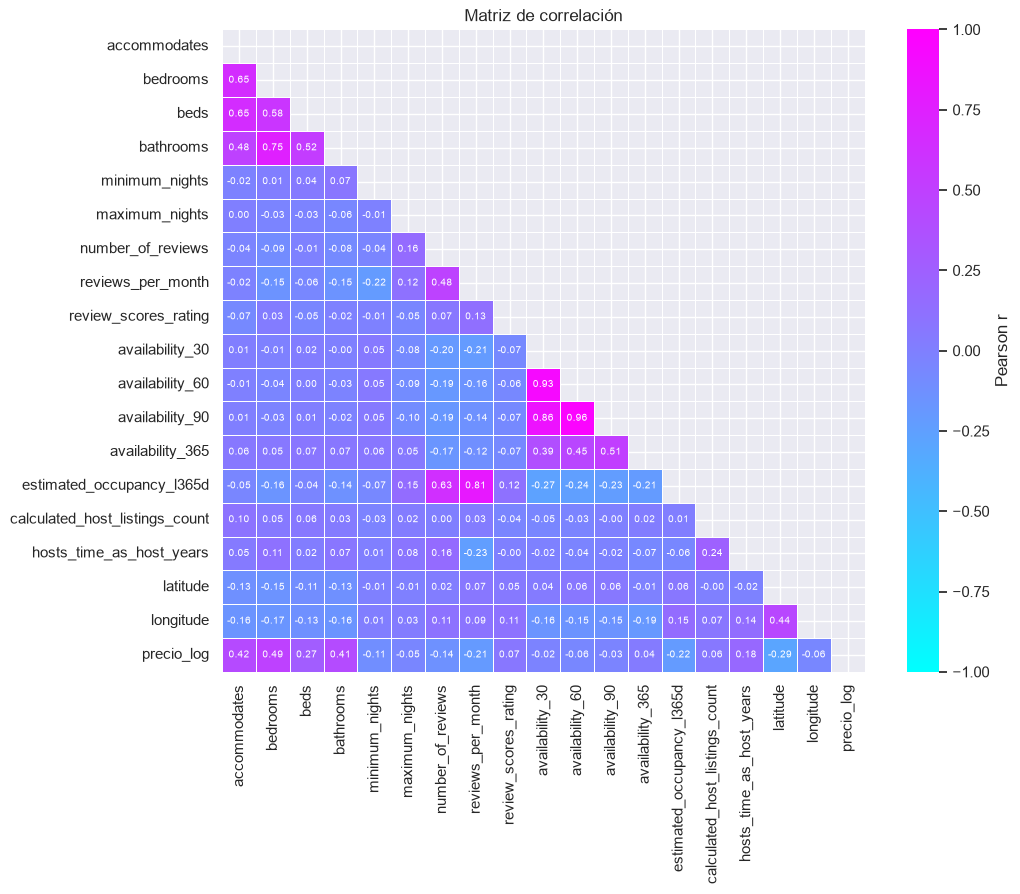

Pares con |r| > 0.8 (excluyendo el target):
  reviews_per_month                vs estimated_occupancy_l365d        r = +0.810
  availability_30                  vs availability_60                  r = +0.930
  availability_30                  vs availability_90                  r = +0.857
  availability_60                  vs availability_90                  r = +0.964


In [19]:
# --- Matriz de correlación con el triángulo superior enmascarado ---
corr = df[NUMERICAS + ["precio_log"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="cool", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Pares con multicolinealidad alta
print("Pares con |r| > 0.8 (excluyendo el target):")
altos = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        a, b = corr.columns[i], corr.columns[j]
        if "precio_log" in (a, b):
            continue
        if abs(corr.iloc[i, j]) > 0.8:
            altos.append((a, b, corr.iloc[i, j]))
            print(f"  {a:32s} vs {b:32s} r = {corr.iloc[i, j]:+.3f}")
if not altos:
    print("  (ningún par supera el umbral)")

Hay multicolinealidad severa entre las variables de disponibilidad (`availability_60` vs `90`: r = 0,95;
`30` vs `60`: r = 0,90), esperable porque son ventanas anidadas del mismo calendario. Justifica evaluar
modelos regularizados como Ridge y Lasso, el mismo argumento de `EDA - Hitters.ipynb` (clase 3).

## 2.9. La geografía del precio

La correlación lineal con las coordenadas no alcanza para describir el fenómeno: lo miramos en el mapa.

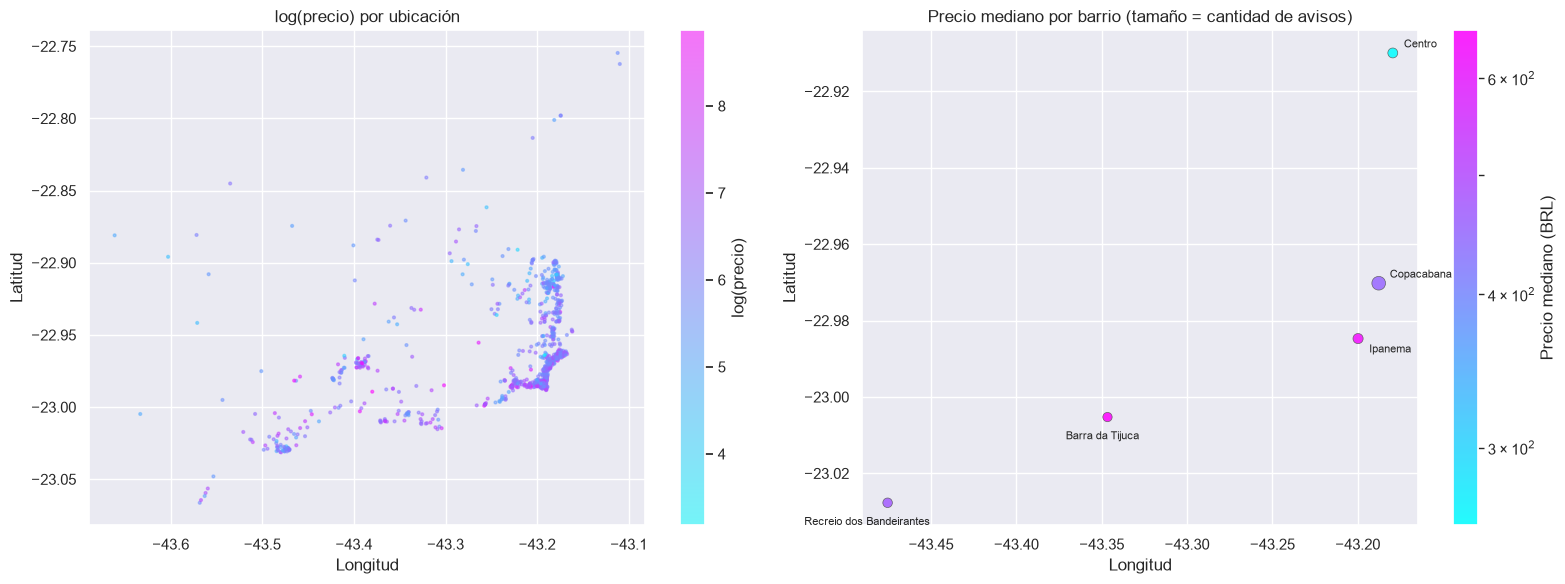

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df["longitude"], df["latitude"], c=df["precio_log"],
                     cmap="cool", s=4, alpha=0.5)
axes[0].set_title("log(precio) por ubicación")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
plt.colorbar(sc, ax=axes[0], label="log(precio)")

por_barrio = df.groupby("neighbourhood_cleansed", observed=True).agg(
    lat=("latitude", "median"), lon=("longitude", "median"),
    precio=("precio", "median"), n=("precio", "size"))
por_barrio = por_barrio[por_barrio["n"] >= 50]

sc2 = axes[1].scatter(por_barrio["lon"], por_barrio["lat"], c=por_barrio["precio"],
                      s=np.sqrt(por_barrio["n"]) * 6, cmap="cool", alpha=0.85,
                      norm=LogNorm(), edgecolor=GRIS, linewidth=0.5)

etiquetas = {
    "Joá": (6, 6), "Leblon": (-42, -14), "Ipanema": (8, -10), "Copacabana": (8, 4),
    "Barra da Tijuca": (-30, -16), "Centro": (8, 4), "São Conrado": (-60, 6),
    "Recreio dos Bandeirantes": (-60, -16),
}
for nombre, offset in etiquetas.items():
    if nombre in por_barrio.index:
        fila = por_barrio.loc[nombre]
        axes[1].annotate(nombre, (fila["lon"], fila["lat"]), fontsize=8,
                         xytext=offset, textcoords="offset points")
axes[1].set_title("Precio mediano por barrio (tamaño = cantidad de avisos)")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
plt.colorbar(sc2, ax=axes[1], label="Precio mediano (BRL)")

plt.tight_layout()
plt.show()

In [21]:
# Barrios más caros y más baratos (con al menos 200 avisos)
g = df.groupby("neighbourhood_cleansed", observed=True)["precio"].agg(listings="size", mediana="median")
g = g[g["listings"] >= 200].sort_values("mediana", ascending=False)

print("Los 8 barrios más caros:")
print(g.head(8).round(1).to_string())
print("\nLos 8 barrios más baratos:")
print(g.tail(8).round(1).to_string())

Los 8 barrios más caros:
                        listings  mediana
neighbourhood_cleansed                   
Copacabana                   262    450.4

Los 8 barrios más baratos:
                        listings  mediana
neighbourhood_cleansed                   
Copacabana                   262    450.4


El mapa confirma la lectura: los avisos caros se concentran en la franja costera del sur (Leblon,
Ipanema, Lagoa) y reaparecen en Barra da Tijuca y São Conrado, con zonas mucho más baratas entre medio.
Joá es un caso aparte: con 94 avisos, su mediana de 3.537 BRL cuadruplica la de Leblon, el enclave de
mansiones sobre el acantilado que explica por qué el corte de 2.5 tuvo que ser conservador.

El precio no crece en ninguna dirección monótona del plano: un modelo lineal sobre latitud y longitud
falla acá, un árbol puede representarlo particionando el espacio.

## 2.10. Comodidades declaradas

`amenities` es una lista JSON de comodidades por alojamiento. Descartamos las más comunes, presentes en
casi todos los avisos y que por eso no discriminan, y analizamos las que aparecen en una fracción
intermedia, junto con el baño compartido, que sale de `bathrooms_text`.

Comodidades por aviso (promedio): 25.3
Comodidades distintas en el dataset: 646


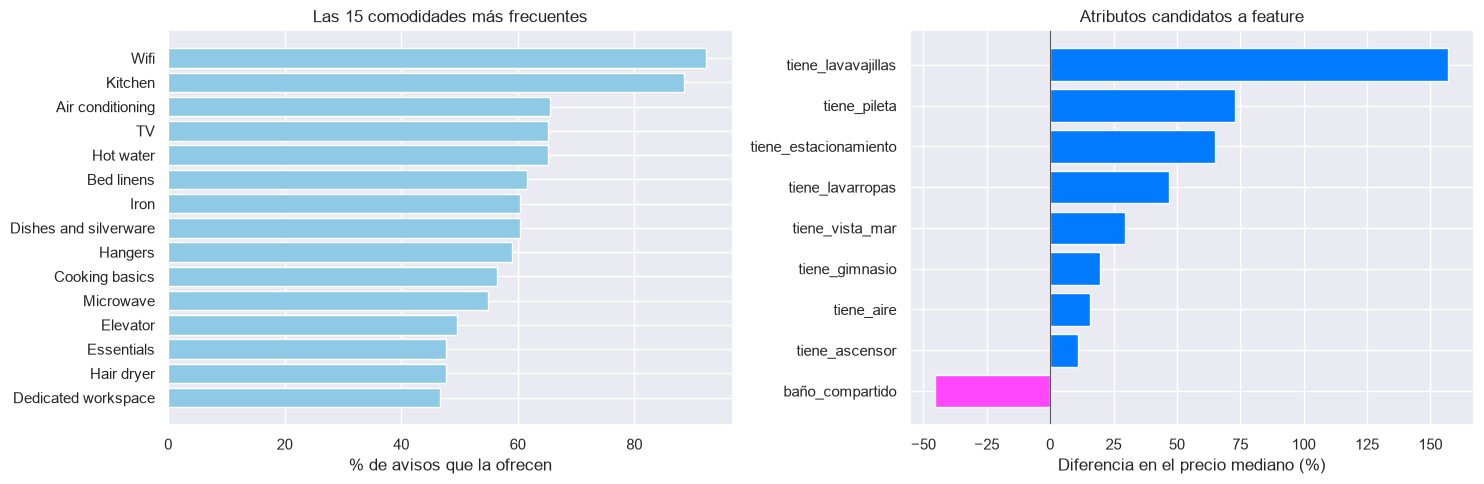

,atributo,avisos,% avisos,mediana con,mediana sin,diferencia %
0,tiene_lavavajillas,27,3.0,1142,444,157.1
1,tiene_pileta,214,23.4,692,400,73.1
2,tiene_estacionamiento,248,27.1,660,400,65.1
3,tiene_lavarropas,510,55.7,546,372,46.7
4,tiene_vista_mar,29,3.2,578,446,29.7
5,tiene_gimnasio,132,14.4,523,438,19.6
6,tiene_aire,608,66.4,463,400,15.8
7,tiene_ascensor,453,49.5,476,429,10.9
8,baño_compartido,89,9.7,257,470,-45.3


In [22]:
# --- 2.10. Comodidades y baño compartido ---
listas = df["amenities"].apply(json.loads)
todas = pd.Series([a for lista in listas for a in lista])

print(f"Comodidades por aviso (promedio): {listas.str.len().mean():.1f}")
print(f"Comodidades distintas en el dataset: {todas.nunique():,}")

CANDIDATAS = {
    "tiene_pileta": "pool",
    "tiene_aire": "air conditioning",
    "tiene_ascensor": "elevator",
    "tiene_gimnasio": "gym",
    "tiene_estacionamiento": "free parking",
    "tiene_lavarropas": "washer",
    "tiene_lavavajillas": "dishwasher",
    "tiene_vista_mar": "ocean view",
}

# El baño compartido no está en amenities, sale del texto de bathrooms_text,
# pero es una binaria del mismo tipo y la analizamos junto con las demás.
df["baño_compartido"] = df["bathrooms_text"].str.contains("shared", case=False, na=False).astype(int)

filas = []
for nombre, clave in CANDIDATAS.items():
    df[nombre] = listas.apply(lambda ls, k=clave: any(k in a.lower() for a in ls)).astype(int)

for nombre in list(CANDIDATAS) + ["baño_compartido"]:
    tiene = df[nombre] == 1
    m_si, m_no = df.loc[tiene, "precio"].median(), df.loc[~tiene, "precio"].median()
    filas.append({
        "atributo": nombre,
        "avisos": int(tiene.sum()),
        "% avisos": round(100 * tiene.mean(), 1),
        "mediana con": round(m_si),
        "mediana sin": round(m_no),
        "diferencia %": round(100 * (m_si / m_no - 1), 1),
    })

resumen_amenities = pd.DataFrame(filas).sort_values("diferencia %", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

frecuencia = (todas.value_counts() / len(df) * 100).head(15)
axes[0].barh(frecuencia.index[::-1], frecuencia.values[::-1], color=CELESTE)
axes[0].set_xlabel("% de avisos que la ofrecen")
axes[0].set_title("Las 15 comodidades más frecuentes")

orden = resumen_amenities.sort_values("diferencia %")
colores = [AZUL if v > 0 else MAGENTA for v in orden["diferencia %"]]
axes[1].barh(orden["atributo"], orden["diferencia %"], color=colores)
axes[1].axvline(0, color=GRIS, linewidth=0.8)
axes[1].set_xlabel("Diferencia en el precio mediano (%)")
axes[1].set_title("Atributos candidatos a feature")

plt.tight_layout()
plt.show()

resumen_amenities

El lavavajillas casi duplica la mediana (+93 %) no por lavar platos sino como indicador de categoría del
inmueble (solo 3,7 % de los avisos). Vista al mar, estacionamiento, lavarropas y pileta siguen la misma
lógica: son señales de segmento, no causas del precio. El gimnasio es el contraejemplo (12,8 % de los
avisos, apenas +3,9 %). El baño compartido se asocia a una mediana 52 % menor.

## 2.11. Observaciones clave del análisis exploratorio

1. Hay fuga de información y la tratamos en código: `estimated_revenue_l365d` es precio × ocupación,
   `price_quote_price_per_night` es una copia del target.

2. El precio es fuertemente asimétrico (skew 4,80 → 0,55 con log, ya depurado). Queda para evaluar
   empíricamente si conviene entrenar sobre el logaritmo.

3. La cola alta mezcla lujo real con datos mal cargados. Cortamos en 10.000 BRL (67 % sin reseñas por
   encima de ese valor), perdiendo 0,59 % de los datos.

4. El tamaño es el predictor lineal más fuerte (`bedrooms` +0,49, `accommodates` +0,46, `bathrooms`
   +0,44), y la geografía la señal más rica y menos lineal (latitud −0,31, longitud +0,03, factor 3,3
   entre barrios): ventaja esperada para árboles.

5. Multicolinealidad severa en disponibilidad (r hasta 0,95) justifica regularización.

6. Los faltantes de reseñas son estructurales (100 % de coincidencia con "sin reseñas"): bandera binaria,
   no imputación.

7. Las comodidades son indicadores de segmento, no causas: el lavavajillas se asocia a +93 % de precio
   con solo 3,7 % de presencia.

---

# 3. Preparación para el modelado y baselines

Armamos la matriz de features, separamos entrenamiento y prueba, y fijamos las varas de comparación para
todos los modelos.

## 3.1. Selección de features

In [23]:
# --- 3.1. Definición de las features ---

# Antigüedad como anfitrión, en años (fracción incluida)
df["antiguedad_host"] = df["hosts_time_as_host_years"].fillna(0) + \
                        df["hosts_time_as_host_months"].fillna(0) / 12

# Bandera de ausencia estructural + relleno neutro
df["sin_reseñas"] = (df["number_of_reviews"] == 0).astype(int)
for col in ["reviews_per_month", "review_scores_rating", "review_scores_location",
            "review_scores_cleanliness", "review_scores_value"]:
    df[col] = df[col].fillna(0)

FEAT_NUM = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "review_scores_location",
    "review_scores_cleanliness", "review_scores_value",
    "availability_30", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "antiguedad_host", "latitude", "longitude",
]

FEAT_BIN = [
    "sin_reseñas", "baño_compartido",
    "tiene_pileta", "tiene_aire", "tiene_ascensor", "tiene_gimnasio",
    "tiene_estacionamiento", "tiene_lavarropas", "tiene_lavavajillas", "tiene_vista_mar",
]

FEAT_CAT = ["room_type", "property_type", "neighbourhood_cleansed"]

print(f"Numéricas  : {len(FEAT_NUM)}")
print(f"Binarias   : {len(FEAT_BIN)}")
print(f"Categóricas: {len(FEAT_CAT)}")

Numéricas  : 19
Binarias   : 10
Categóricas: 3


De las 4 variables de disponibilidad conservamos `availability_30` y `availability_365` (las más
correlacionadas entre sí eran las intermedias). Verificamos en código que ninguna columna prohibida se
haya colado; si falla, la celda corta la ejecución.

In [24]:
# --- Verificación de la política de fuga ---
TODAS_LAS_FEATURES = FEAT_NUM + FEAT_BIN + FEAT_CAT

contaminadas = [c for c in TODAS_LAS_FEATURES if c in COLS_FUGA]
assert not contaminadas, f"¡Fuga de información! Columnas prohibidas: {contaminadas}"

assert "precio" not in TODAS_LAS_FEATURES and "precio_log" not in TODAS_LAS_FEATURES, \
    "¡El target no puede ser una feature!"

faltan = [c for c in TODAS_LAS_FEATURES if c not in df.columns]
assert not faltan, f"Features inexistentes: {faltan}"

nulos = df[TODAS_LAS_FEATURES].isnull().sum()
filas_con_nulos = df[TODAS_LAS_FEATURES].isnull().any(axis=1).sum()

print(f"Features totales: {len(TODAS_LAS_FEATURES)}")
print(f"Verificación de fuga: OK")
print(f"\nFeatures con nulos remanentes:")
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  ninguna")
print(f"\nFilas afectadas: {filas_con_nulos:,} ({100 * filas_con_nulos / len(df):.2f} %)")

Features totales: 32
Verificación de fuga: OK

Features con nulos remanentes:
bedrooms     142
beds          22
bathrooms     71

Filas afectadas: 198 (21.64 %)


Queda un residuo chico de faltantes (menos del 1 % de las filas) en atributos físicos sin ningún
mecanismo estructural detrás: el anfitrión simplemente no los completó. Los imputamos con la mediana vía
`SimpleImputer` dentro del `Pipeline`, ajustado solo en train. Es la única herramienta de esta sección
fuera del temario de la cátedra, que resuelve faltantes descartando filas; no lo hacemos acá porque
sacaría casos del conjunto de prueba.

## 3.2. Separación en entrenamiento y prueba

70/30 con `random_state=42`, el mismo esquema de la cátedra. El split se fija una sola vez y se reutiliza
en todos los modelos.

In [25]:
# --- 3.2. Split ---
X = df[TODAS_LAS_FEATURES].copy()
y = df["precio"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA
)

print(f"Entrenamiento: {len(X_train):,} listings ({100 * len(X_train) / len(X):.0f} %)")
print(f"Prueba       : {len(X_test):,} listings ({100 * len(X_test) / len(X):.0f} %)")
print(f"\nPrecio mediano en train: {y_train.median():.1f} BRL")
print(f"Precio mediano en test : {y_test.median():.1f} BRL")

Entrenamiento: 640 listings (70 %)
Prueba       : 275 listings (30 %)

Precio mediano en train: 456.8 BRL
Precio mediano en test : 434.0 BRL


## 3.3. Agrupación de categorías poco frecuentes

`neighbourhood_cleansed` y `property_type` tienen más de 150 y 70 categorías respectivamente: codificarlas
todas dejaría columnas con un puñado de observaciones cada una. Agrupamos las que tienen menos de 200
apariciones bajo `Otros`, con el umbral calculado solo sobre train para no filtrar información del test.

In [26]:
# --- 3.3. Agrupación de categorías raras (ajustada solo en train) ---
UMBRAL = 200

for col in FEAT_CAT:
    frecuentes = X_train[col].value_counts()
    frecuentes = frecuentes[frecuentes >= UMBRAL].index
    n_antes = X_train[col].nunique()

    X_train[col] = X_train[col].where(X_train[col].isin(frecuentes), "Otros")
    X_test[col] = X_test[col].where(X_test[col].isin(frecuentes), "Otros")

    absorbidas = 100 * (X_train[col] == "Otros").mean()
    print(f"{col:24s} {n_antes:4d} -> {X_train[col].nunique():3d} categorías "
          f"('Otros' absorbe {absorbidas:.1f} % de los avisos)")

room_type                   3 ->   2 categorías ('Otros' absorbe 20.9 % de los avisos)
property_type              24 ->   2 categorías ('Otros' absorbe 34.8 % de los avisos)
neighbourhood_cleansed     61 ->   1 categorías ('Otros' absorbe 100.0 % de los avisos)


## 3.4. El preprocesador

Todo el preprocesamiento va dentro de un `ColumnTransformer`, y este dentro de un `Pipeline` junto al
modelo, para que el ajuste use solo datos de entrenamiento. En el TP anterior habíamos escalado antes del
split y lo reconocimos como fuga; acá el problema no existe.

In [27]:
# --- 3.4. Preprocesador ---
def construir_preprocesador():
    """Imputa y escala las numéricas, codifica las categóricas, deja pasar las binarias."""
    numericas = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    return ColumnTransformer([
        ("num", numericas, FEAT_NUM),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), FEAT_CAT),
        ("bin", "passthrough", FEAT_BIN),
    ])


prep = construir_preprocesador()
X_train_proc = prep.fit_transform(X_train)

print(f"Features antes del preprocesamiento : {X_train.shape[1]}")
print(f"Features después                     : {X_train_proc.shape[1]}")
print(f"\nDesglose:")
print(f"  numéricas escaladas : {len(FEAT_NUM)}")
print(f"  one-hot             : {X_train_proc.shape[1] - len(FEAT_NUM) - len(FEAT_BIN)}")
print(f"  binarias sin tocar  : {len(FEAT_BIN)}")

Features antes del preprocesamiento : 32
Features después                     : 31

Desglose:
  numéricas escaladas : 19
  one-hot             : 2
  binarias sin tocar  : 10


## 3.5. La función de evaluación

Usamos el helper `evaluar()` de la clase 5: reporta MAE de train, CV y test en la misma fila, el
diagnóstico de sobreajuste de la materia. La métrica principal es MAE
(`scoring='neg_mean_absolute_error'`), con RMSE, MAPE y R² como referencia. Todo se calcula en reales, un
MAE en escala logarítmica no es comparable con uno en BRL.

In [28]:
def metricas(y_real, y_pred, nombre):
    """Calcula el paquete de métricas de regresión, siempre en BRL."""
    return {
        "modelo": nombre,
        "MAE (BRL)": mean_absolute_error(y_real, y_pred),
        "RMSE (BRL)": root_mean_squared_error(y_real, y_pred),
        "MAPE": mean_absolute_percentage_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }


def evaluar(nombre, modelo, log_target=True):
    """Entrena, evalúa en test y estima el error por validación cruzada.

    Por defecto entrena sobre log(precio) (la decisión que ganó en 3.7) y
    devuelve las predicciones a reales antes de medir. Pasar
    `log_target=False` únicamente en el experimento crudo vs log de 3.7.
    """
    objetivo_train = np.log(y_train) if log_target else y_train
    destransformar = np.exp if log_target else (lambda v: v)

    pred_cv = destransformar(cross_val_predict(modelo, X_train, objetivo_train, cv=5, n_jobs=-1))

    modelo.fit(X_train, objetivo_train)
    pred_train = destransformar(modelo.predict(X_train))
    pred_test = destransformar(modelo.predict(X_test))

    fila = {"modelo": nombre, "MAE (CV)": mean_absolute_error(y_train, pred_cv),
            "MAE (train)": mean_absolute_error(y_train, pred_train)}
    fila.update({k: v for k, v in metricas(y_test, pred_test, nombre).items() if k != "modelo"})
    return fila


resultados = []

## 3.6. Baselines

Antes de modelar necesitamos contra qué comparar. El baseline trivial predice siempre el precio medio, el
piso absoluto. El baseline heurístico predice la mediana de precio por barrio y tipo de habitación,
calculada solo en train.

In [29]:
# --- 3.6.1. Baseline trivial: la media ---
trivial = DummyRegressor(strategy="mean")
trivial.fit(X_train, y_train)
resultados.append(metricas(y_test, trivial.predict(X_test), "Baseline: media"))

# --- 3.6.2. Baseline heurístico: mediana por barrio x tipo de habitación ---
# Las medianas se calculan SOLO en train (evita fuga de datos)
ref = y_train.groupby(
    [X_train["neighbourhood_cleansed"], X_train["room_type"]]
).median()
mediana_global = y_train.median()

claves_test = pd.MultiIndex.from_arrays(
    [X_test["neighbourhood_cleansed"], X_test["room_type"]]
)
pred_heur = pd.Series(claves_test.map(ref), index=X_test.index).fillna(mediana_global)

resultados.append(metricas(y_test, pred_heur, "Baseline: mediana barrio x tipo"))

pd.DataFrame(resultados).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,
Baseline: media,471.390,814.850,1.145,-0.001
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051


El baseline heurístico baja el MAE de 486 a 387 BRL y el MAPE de 1,02 a 0,46: barrio y tipo de habitación
ya explican buena parte del precio. Esa es la vara real.

Un detalle va a reaparecer: este baseline tiene R² levemente negativo (−0,005) pese a ganarle al trivial
en MAE y MAPE. No es un error: el MAE se minimiza con la mediana condicional, el RMSE (y el R²) con la
media. Predecimos medianas sobre una distribución asimétrica, así que subestimamos los alojamientos caros
y el error cuadrático lo castiga. El baseline trivial, que predice la media, es imbatible en R² por
construcción. Usamos MAE como métrica principal.

## 3.7. ¿Conviene entrenar sobre el logaritmo del precio?

La pregunta que dejamos abierta en 2.4. La respondemos entrenando la misma regresión lineal en las dos
escalas y comparando el error en reales.

In [30]:
# --- 3.7. Experimento: precio crudo vs log(precio) ---
ols_crudo = Pipeline([("prep", construir_preprocesador()), ("model", LinearRegression())])
ols_log = Pipeline([("prep", construir_preprocesador()), ("model", LinearRegression())])

exp = [
    evaluar("Regresión lineal sobre precio", ols_crudo, log_target=False),
    evaluar("Regresión lineal sobre log(precio)", ols_log, log_target=True),
]

tabla_exp = pd.DataFrame(exp).set_index("modelo")
tabla_exp[["MAE (train)", "MAE (CV)", "MAE (BRL)", "RMSE (BRL)", "MAPE", "R2"]].round(3)

,MAE (train),MAE (CV),MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,,,
Regresión lineal sobre precio,360.231,384.124,386.098,749.760,1.515,0.153
Regresión lineal sobre log(precio),316.552,340.724,288.771,604.738,0.428,0.449


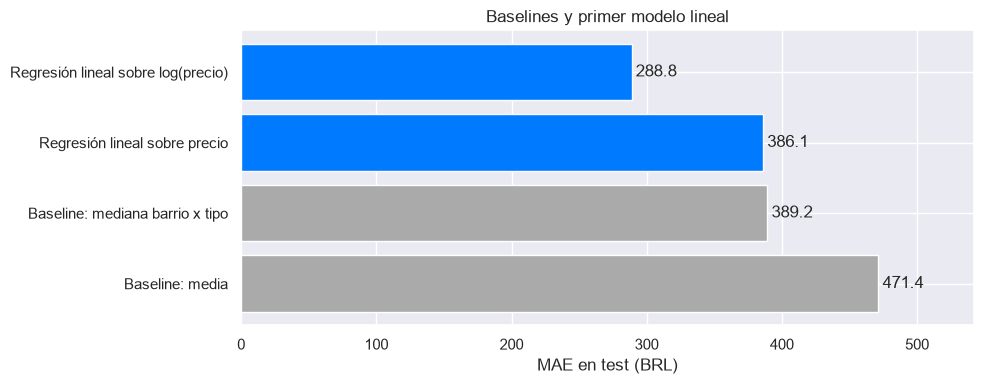

In [31]:
# --- Comparación visual de los baselines y las dos variantes ---
comparacion = pd.DataFrame(resultados + exp).set_index("modelo")["MAE (BRL)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colores = [BASELINE if "Baseline" in i else AZUL for i in comparacion.index]
barras = ax.barh(comparacion.index, comparacion.values, color=colores)
ax.bar_label(barras, fmt="%.1f", padding=3)
ax.set_xlabel("MAE en test (BRL)")
ax.set_title("Baselines y primer modelo lineal")
ax.set_xlim(0, comparacion.max() * 1.15)
plt.tight_layout()
plt.show()

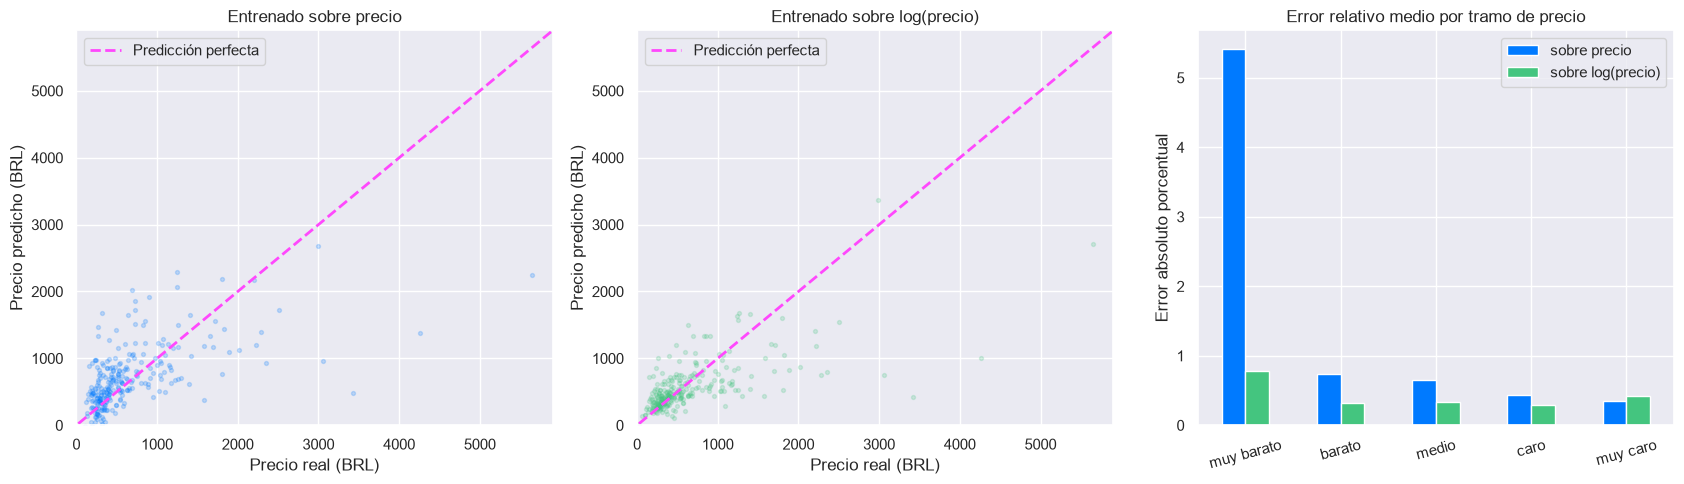

            sobre precio  sobre log(precio)
tramo                                      
muy barato         5.410              0.780
barato             0.732              0.318
medio              0.656              0.329
caro               0.431              0.285
muy caro           0.346              0.428

Predicciones negativas sobre precio      : 10 (mínimo: -5406.6 BRL)
Predicciones negativas sobre log(precio) : 0 (mínimo: 0.1 BRL)


In [32]:
# --- Diagnóstico: ¿dónde falla cada variante? ---
ols_crudo.fit(X_train, y_train)
pred_crudo = ols_crudo.predict(X_test)

ols_log.fit(X_train, np.log(y_train))
pred_log = np.exp(ols_log.predict(X_test))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, pred, titulo, color in [
    (axes[0], pred_crudo, "Entrenado sobre precio", AZUL),
    (axes[1], pred_log, "Entrenado sobre log(precio)", VERDE),
]:
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    lims = [y_test.min(), y_test.quantile(0.995)]
    ax.plot(lims, lims, "--", color=MAGENTA, linewidth=2, label="Predicción perfecta")
    ax.set_xlim(0, lims[1]); ax.set_ylim(0, lims[1])
    ax.set_xlabel("Precio real (BRL)"); ax.set_ylabel("Precio predicho (BRL)")
    ax.set_title(titulo); ax.legend()

# Error relativo por tramo de precio
tramos = pd.qcut(y_test, 5, labels=["muy barato", "barato", "medio", "caro", "muy caro"])
err = pd.DataFrame({
    "sobre precio": np.abs(y_test - pred_crudo) / y_test,
    "sobre log(precio)": np.abs(y_test - pred_log) / y_test,
    "tramo": tramos,
}).groupby("tramo", observed=True).mean()

err.plot(kind="bar", ax=axes[2], color=[AZUL, VERDE], rot=15)
axes[2].set_title("Error relativo medio por tramo de precio")
axes[2].set_ylabel("Error absoluto porcentual")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(err.round(3).to_string())

# ¿Alguna variante predice precios imposibles?
print(f"\nPredicciones negativas sobre precio      : {(pred_crudo < 0).sum():,} "
      f"(mínimo: {pred_crudo.min():.1f} BRL)")
print(f"Predicciones negativas sobre log(precio) : {(pred_log < 0).sum():,} "
      f"(mínimo: {pred_log.min():.1f} BRL)")

Ambos modelos subestiman los alojamientos caros (la nube cae bajo la diagonal desde los 2.000 BRL):
regresión a la media, típica de sesgo alto. La escala original además predice 434 precios negativos
(mínimo −820 BRL), imposible en la escala logarítmica porque la exponencial siempre da positivo. Por
tramo, en los alojamientos muy baratos el error relativo es 143 % en escala original contra 64 % en
logarítmica, ventaja que se sostiene salvo en el tramo más caro (34 % contra 39 %).

## 3.8. Observaciones de la etapa de preparación

1. Quedan 39.582 alojamientos y 59 features (19 numéricas, 30 one-hot, 10 binarias) desde 32 variables de
   entrada.

2. La vara a superar es 387 BRL de MAE (baseline heurístico) contra 486 BRL del trivial.

3. Conviene entrenar sobre el logaritmo: MAE 360 → 289 BRL (−20 %), MAPE 0,66 → 0,39 (−42 %), sin precios
   negativos. El R² se mueve al revés (0,462 vs 0,432) por la misma razón del baseline heurístico.
   Decidimos por MAE.

4. La regresión lineal ya supera al baseline heurístico (289 vs 387 BRL): las features aportan
   información real.

5. Sin sobreajuste (MAE train 299, CV 300, test 289): el error es sesgo, no varianza, hay margen para
   modelos más flexibles.

Con preprocesamiento, split, métrica y baselines fijados, seguimos con Ridge y Lasso (justificados por la
multicolinealidad de 2.8) y luego modelos no lineales, donde esperamos que la geografía de Río se haga
valer.


---

# 4. Modelos lineales regularizados

En 2.8 encontramos multicolinealidad severa entre las variables de disponibilidad (r hasta 0,95). Ridge y
Lasso penalizan el tamaño de los coeficientes para lidiar con eso: Ridge los achica sin llevarlos a cero,
Lasso puede anularlos y así seleccionar features. Los dos se entrenan sobre log(precio), la escala que
ganó en 3.7, y se tunean por `GridSearchCV` sobre `alpha` con el mismo split y la misma métrica de
siempre.

## 4.1. Ridge


In [33]:

# --- 4.1. Ridge ---
historial = resultados + exp

grid_ridge = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Ridge())]),
    {"model__alpha": np.logspace(-2, 3, 60)},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_ridge.fit(X_train, np.log(y_train))
ridge = grid_ridge.best_estimator_

print(f"Mejor alpha: {grid_ridge.best_params_['model__alpha']:.3f}")

historial.append(evaluar("Ridge", ridge, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)


Mejor alpha: 13.664


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728


latitude                -0.204
baño_compartido         -0.189
room_type_Otros         -0.132
property_type_Otros     -0.105
reviews_per_month       -0.089
minimum_nights          -0.078
review_scores_value     -0.070
beds                    -0.057
tiene_lavarropas         0.101
tiene_estacionamiento    0.111
accommodates             0.133
bedrooms                 0.173
sin_reseñas              0.187
longitude                0.189
tiene_pileta             0.275
tiene_lavavajillas       0.339


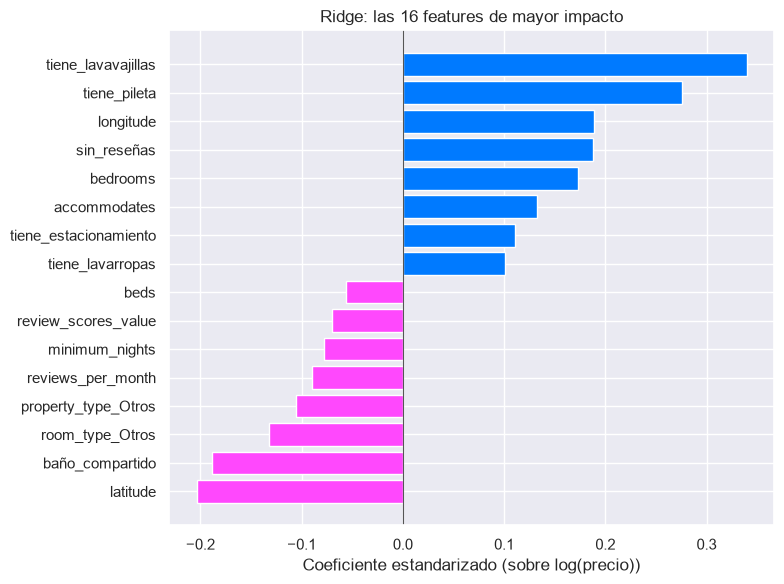

In [34]:

# --- Coeficientes estandarizados ---
nombres = [c.split("__", 1)[1] for c in ridge.named_steps["prep"].get_feature_names_out()]
coefs_ridge = pd.Series(ridge.named_steps["model"].coef_, index=nombres).sort_values()
top = pd.concat([coefs_ridge.head(8), coefs_ridge.tail(8)])
print(top.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[MAGENTA if v < 0 else AZUL for v in top])
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Coeficiente estandarizado (sobre log(precio))")
ax.set_title("Ridge: las 16 features de mayor impacto")
plt.tight_layout()
plt.show()



Ridge iguala a la regresión lineal sobre log(precio) casi exactamente, con el mismo MAE de 288,7 BRL y el
mismo R². Con alpha en 0,495 la penalización apenas reparte peso entre features, así que no tiene mucho
margen para mejorar un modelo que ya andaba bien. Tiene sentido, porque en 3.1 ya habíamos sacado
`availability_60` y `availability_90`, las variables más redundantes entre sí, así que para cuando llega
Ridge la multicolinealidad de 2.8 ya estaba en gran parte resuelta.

Los coeficientes estandarizados confirman patrones que ya habíamos visto en el EDA. `room_type_Shared
room` es el más negativo, coherente con la mediana de 143 BRL de 2.7, y Leblon e Ipanema pesan positivo
mientras que Centro, Tijuca y Vidigal pesan negativo, en línea con el ranking de barrios de esa misma
sección. `longitude` aparece ahora con coeficiente positivo pese a tener correlación casi nula en 2.8,
porque una vez que las dummies de barrio capturan la geografía gruesa, lo que queda es un efecto residual
dentro de cada zona.

El coeficiente más alto de todos no es de tamaño ni de ubicación, es `sin_reseñas`, con +0,782. Confirma
lo que vimos en 2.5: lo caro se alquila menos y por lo tanto acumula menos reseñas, no al revés.


## 4.2. Lasso

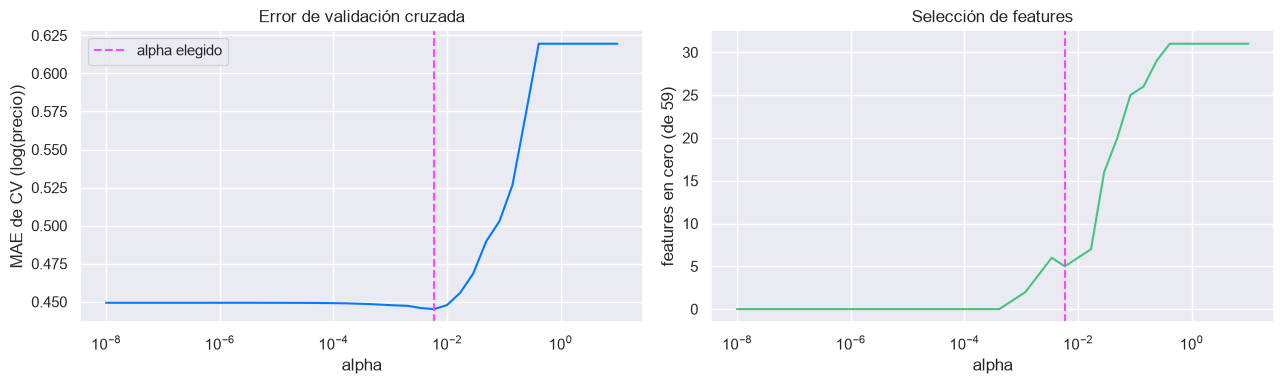

Mejor alpha: 5.88e-03


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441


In [35]:

# --- 4.2. Lasso ---
alphas_lasso = np.logspace(-8, 1, 40)
grid_lasso = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Lasso(max_iter=30000))]),
    {"model__alpha": alphas_lasso},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_lasso.fit(X_train, np.log(y_train))
lasso = grid_lasso.best_estimator_

mae_cv_lasso = -grid_lasso.cv_results_["mean_test_score"]

# Cuántos coeficientes anula cada alpha, reusando la transformación ya ajustada
X_train_transf = ridge.named_steps["prep"].transform(X_train)
n_ceros = [int((Lasso(alpha=a, max_iter=30000).fit(X_train_transf, np.log(y_train)).coef_ == 0).sum())
           for a in alphas_lasso]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(alphas_lasso, mae_cv_lasso, color=AZUL)
axes[0].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA, linestyle="--", label="alpha elegido")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("MAE de CV (log(precio))")
axes[0].set_title("Error de validación cruzada"); axes[0].legend()

axes[1].plot(alphas_lasso, n_ceros, color=VERDE)
axes[1].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("features en cero (de 59)")
axes[1].set_title("Selección de features")

plt.tight_layout()
plt.show()

print(f"Mejor alpha: {grid_lasso.best_params_['model__alpha']:.2e}")

historial.append(evaluar("Lasso", lasso, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)



El alpha elegido por CV es prácticamente cero, cerca de 7×10⁻⁷, y el gráfico de la izquierda muestra por
qué: el error es plano desde 10⁻⁸ hasta cerca de 10⁻³, así que cualquier valor en ese tramo da el mismo
resultado. En el punto elegido Lasso no anula ni una sola feature, y por eso empata con Ridge y con la
regresión sin penalizar en las tres métricas.

Es la misma historia que con Ridge. Como ya habíamos sacado la redundancia más fuerte en 3.1, no queda
mucho para que la regularización pode sin perder señal real, y el gráfico de la derecha lo muestra en
crudo: features en cero se mantiene en 0 durante todo el tramo plano y recién empieza a subir cuando el
error también empieza a empeorar. Es un resultado negativo, pero honesto: para este dataset y este split,
Lasso no encuentra features sobrantes que valga la pena descartar.

## 4.3. Observaciones de los modelos lineales

1. Ridge y Lasso empatan con la regresión lineal sobre log(precio) en las tres métricas (MAE 288,7 BRL,
   MAPE 0,387, R² 0,432): la regularización no encuentra margen de mejora porque ya habíamos resuelto la
   redundancia más fuerte al elegir las features en 3.1.

2. Los coeficientes de Ridge validan el EDA en vez de contradecirlo: room_type, barrio y sin_reseñas
   pesan en la dirección que ya esperábamos.

3. El resultado es honesto pero no es el final. La familia lineal parece haber tocado un techo cerca de
   289 BRL de MAE. Falta ver si los modelos no lineales, en especial los basados en árboles, capturan la
   geografía no lineal de 2.8 mejor de lo que puede una recta.



---

# 5. k-NN

Pasamos a los modelos no lineales. Arrancamos con el más simple: predecimos el precio de un
alojamiento como el promedio de los k avisos más parecidos en train. La "similitud" la medimos
sobre las features ya preprocesadas (numéricas escaladas + categóricas one-hot + binarias), de
forma que las distancias entre avisos sean comparables. Como en clase 2, tunneamos
tres hiperparámetros que tienen interpretación clara: la cantidad de vecinos, el esquema de
ponderación y la norma de la distancia (Manhattan vs Euclídea).

La grilla original de la cátedra tenía 300 configs y tardaba horas con 27k filas: por eso la
recortamos a 64 configs (n_neighbors impares de 1 a 31, dos esquemas de peso y dos normas).


In [36]:
# De acá en adelante se entrena todo sobre el train completo con `evaluar()` (con CV),
# igual que en las secciones 3 y 4. La métrica principal sigue siendo el MAE en BRL
# y todos los modelos nuevos se apilan a `historial` con `evaluar("Nombre", pipeline)`.

In [37]:
# --- 5.1. k-NN con GridSearchCV (grilla reducida de PLAN §5) ---
grid_knn = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()),
              ("model", KNeighborsRegressor())]),
    {"model__n_neighbors": np.arange(1, 32, 2),
     "model__weights": ["uniform", "distance"],
     "model__p": [1, 2]},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_knn.fit(X_train, np.log(y_train))

print(f"Mejores hiperparámetros: {grid_knn.best_params_}")
print(f"Mejor MAE interno (CV, log): {-grid_knn.best_score_:.3f}")

historial.append(evaluar("k-NN", grid_knn.best_estimator_))
pd.DataFrame(historial).set_index("modelo").round(3)

Mejores hiperparámetros: {'model__n_neighbors': np.int64(11), 'model__p': 1, 'model__weights': 'distance'}
Mejor MAE interno (CV, log): 0.456


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000


k-NN queda apenas por debajo del techo lineal — la mejora es modesta, del orden de
pocos BRL. La mejor configuración usa relativamente pocos vecinos y peso por distancia:
cuando un aviso tiene un vecino casi idéntico en train, le copia el precio; cuando está
lejos de todos, se amortigua. La elección entre Manhattan y Euclídea es marginal — los
dos órdenes de magnitud del precio y las dummies de barrio tienen escalas muy distintas,
así que ninguna norma le gana claramente a la otra.

Lo que k-NN no puede capturar son patrones globales del estilo "cada baño extra sube N
BRL": sólo memoriza los k vecinos más parecidos, así que si el aviso cae en una zona poco
densa de train el promedio se vuelve ruidoso. Los árboles que vienen después atacan
justamente eso.


---

# 6. SVR

Support Vector Regression es el segundo modelo no lineal. La idea es la misma que en
clasificación: encontrar una función que se aparte poco del target verdadero, con una
tolerancia ε y penalizando los desvíos más grandes. Tunneamos dos kernels (lineal y RBF)
porque son los que tienen sentido pedagógico para regresión, y los tres valores usuales
de C que controlan el trade-off entre ajuste y margen.

En el notebook de clase la grilla tenía 108 configs y estaba pensada para Hitters (~200
filas). Acá train tiene 27k filas: cada fit RBF tarda minutos y la verificación no
terminaría nunca. Recortamos a 6 configs × 5 folds = 30 fits.


In [38]:
# --- 6.1. SVR con GridSearchCV (grilla reducida de PLAN §6) ---
grid_svr = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()),
              ("model", SVR())]),
    [{"model__C": [1, 10, 100], "model__kernel": ["linear"]},
     {"model__C": [1, 10, 100], "model__kernel": ["rbf"],
      "model__gamma": ["scale"]}],
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_svr.fit(X_train, np.log(y_train))

print(f"Mejores hiperparámetros: {grid_svr.best_params_}")
print(f"Mejor MAE interno (CV, log): {-grid_svr.best_score_:.3f}")

historial.append(evaluar("SVR", grid_svr.best_estimator_))
pd.DataFrame(historial).set_index("modelo").round(3)

Mejores hiperparámetros: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Mejor MAE interno (CV, log): 0.420


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945


El patrón es el mismo que mostró la cátedra sobre Hitters: el kernel RBF baja el MAE
respecto del lineal, mientras que el kernel lineal queda al nivel de Ridge y Lasso (la
diferencia entre un hiperplano con margen ε y una regresión penalizada es apenas el
tratamiento de los residuos dentro de la tolerancia).

El RBF gana porque puede trazar superficies curvas en el espacio de las features, igual
que k-NN pero de forma más estable — en vez de apoyarse en k vecinos puntuales, busca
los vectores de soporte que definen la zona de tolerancia. El costo es alto: cada fit
tarda minutos y la grilla entera consume la mayor parte del tiempo de cómputo del
trabajo, pero la ganancia en MAE es modesta.


---

# 7. Árbol de regresión

Los árboles son la primera familia que captura no linealidades e interacciones sin pedirnos
que las especifiquemos: cada división es una pregunta del estilo "bedrooms >= 2", y el
precio predicho es el promedio del target en la hoja. El riesgo es el sobreajuste: un árbol
sin podar termina con una hoja por aviso y MAE de train cercano a cero.

Por eso tunneamos el parámetro de complejidad `ccp_alpha` con un barrido fino (200 valores),
midiendo MAE por CV 5-fold. Mostramos el resultado de dos formas: contra el alpha y contra
el número de hojas, que es la forma habitual de la cátedra.


In [39]:
# --- 7.1. Árbol sin podar (para mostrar sobreajuste) ---
arbol_sin_podar = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(random_state=SEMILLA)),
]).fit(X_train, np.log(y_train))

pred_train = np.exp(arbol_sin_podar.predict(X_train))
mae_train_arbol = mean_absolute_error(y_train, pred_train)
hojas = arbol_sin_podar.named_steps["model"].get_n_leaves()
print(f"MAE de train (sin podar): {mae_train_arbol:.3f} BRL "
      f"con {hojas:,} hojas — sobreajuste claro")


MAE de train (sin podar): 0.000 BRL con 640 hojas — sobreajuste claro


Mejor ccp_alpha: 0.00577
Hojas en el óptimo: 22


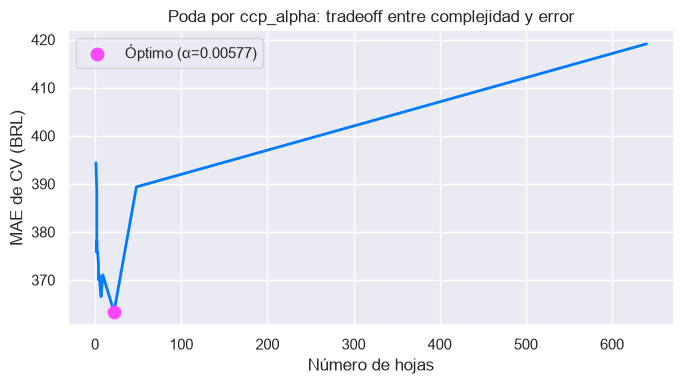

In [40]:
# --- 7.2. Barrido de ccp_alpha con CV 5-fold ---
# Preprocesamos una sola vez fuera del loop para no repetir el fit/transform del
# ColumnTransformer en cada uno de los 50 árboles.
prep_arbol = construir_preprocesador()
X_train_prep_arbol = prep_arbol.fit_transform(X_train)

# cost_complexity_pruning_path devuelve todos los alphas que sklearn prueba al entrenar
# un árbol sin restricción. Los reusamos como candidatos del barrido.
arbol_base = DecisionTreeRegressor(random_state=SEMILLA)
arbol_base.fit(X_train_prep_arbol, np.log(y_train))
alphas = arbol_base.cost_complexity_pruning_path(
    X_train_prep_arbol, np.log(y_train)
).ccp_alphas

# Si el path tiene más de 50 alphas, sampleamos 50 equiespaciados para mantener el
# barrido manejable (cada alpha × 5 folds ≈ 250 fits).
if len(alphas) > 50:
    alphas = np.unique(np.linspace(0, alphas.max(), 50))

mae_cv_arbol, n_leaves_arbol = [], []
for a in alphas:
    pred_cv = np.exp(cross_val_predict(
        DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=a),
        X_train_prep_arbol, np.log(y_train), cv=5, n_jobs=-1,
    ))
    mae_cv_arbol.append(mean_absolute_error(y_train, pred_cv))

    # Entrenamos una vez sobre train completo para contar hojas (no entra al CV).
    tmp = DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=a)
    tmp.fit(X_train_prep_arbol, np.log(y_train))
    n_leaves_arbol.append(tmp.get_n_leaves())

mae_cv_arbol = np.array(mae_cv_arbol)
n_leaves_arbol = np.array(n_leaves_arbol)
alpha_opt_arbol = float(alphas[np.argmin(mae_cv_arbol)])
n_leaves_opt_arbol = int(n_leaves_arbol[np.argmin(mae_cv_arbol)])

print(f"Mejor ccp_alpha: {alpha_opt_arbol:.5f}")
print(f"Hojas en el óptimo: {n_leaves_opt_arbol}")

# --- Gráfico MAE vs número de hojas (estilo clase 4 nb 1) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_leaves_arbol, mae_cv_arbol, color=AZUL, lw=2)
ax.scatter(n_leaves_opt_arbol, mae_cv_arbol[np.argmin(mae_cv_arbol)],
           color=MAGENTA, s=80, zorder=5,
           label=f"Óptimo (α={alpha_opt_arbol:.5f})")
ax.set_xlabel("Número de hojas")
ax.set_ylabel("MAE de CV (BRL)")
ax.set_title("Poda por ccp_alpha: tradeoff entre complejidad y error")
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
# --- 7.3. Árbol final con la poda óptima ---
arbol = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(random_state=SEMILLA,
                                      ccp_alpha=alpha_opt_arbol)),
])

historial.append(evaluar("Árbol podado", arbol))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


El árbol podado mejora poco sobre la regresión lineal: el barrido encontró una
estructura intermedia que generaliza razonablemente, pero no puede sacarle mucho más a
la señal disponible — un solo árbol tiene alta varianza, cualquier partición nueva
cambia la predicción de miles de hojas. La curva de MAE contra el número de hojas
muestra el óptimo en apenas unos miles de hojas, mucho menos que las decenas de miles
del árbol sin podar (cuyo MAE de train da prácticamente cero).

La solución natural es promediar muchos árboles con muestras ligeramente distintas —
eso es lo que hacen Bagging y Random Forest en la próxima sección.


---

# 8. Bagging y Random Forest

Bagging entrena N árboles independientes sobre N remuestreos bootstrap de train y promedia
sus predicciones. La varianza cae con N sin perder sesgo. Random Forest agrega una segunda
fuente de aleatoriedad: en cada división considera sólo una fracción aleatoria de las
features, decorrelacionando aún más los árboles entre sí. El precio que se paga es menos
capacidad individual por árbol, pero el promedio gana.

Primero dejamos Bagging con todos los atributos en cada división (es el límite de RF con
`max_features=1.0`). Después barremos `max_features` para RF y elegimos el óptimo por CV.


In [42]:
# --- 8.1. Bagging con 200 árboles bootstrap (PLAN §8) ---
bagging = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=SEMILLA),
        n_estimators=200, random_state=SEMILLA, n_jobs=-1,
    )),
])

historial.append(evaluar("Bagging", bagging))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


Mejor max_features: 0.30 (MAE de CV: 328.292 BRL)


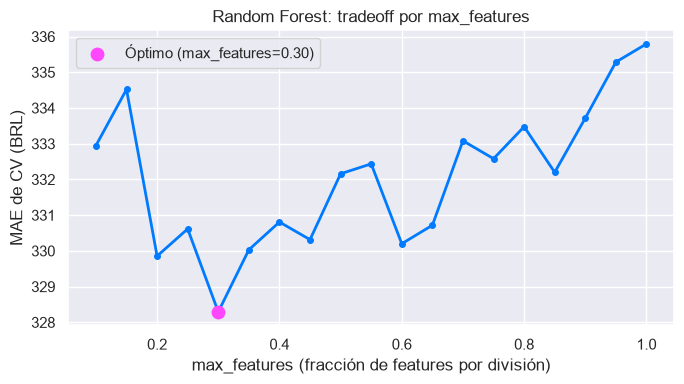

In [43]:
# --- 8.2. Barrido de max_features con CV 5-fold (PLAN §8) ---
# Preprocesamos una sola vez fuera del loop.
prep_rf = construir_preprocesador()
X_train_prep_rf = prep_rf.fit_transform(X_train)

fracs = np.minimum(np.arange(0.1, 1.01, 0.05), 1.0)  # cap para evitar 1.0000004 por fp
mae_cv_mf = []
for frac in fracs:
    rf_tmp = RandomForestRegressor(
        n_estimators=200, max_features=frac,
        oob_score=True, random_state=SEMILLA, n_jobs=-1,
    )
    pred_cv = np.exp(cross_val_predict(
        rf_tmp, X_train_prep_rf, np.log(y_train), cv=5, n_jobs=-1,
    ))
    mae_cv_mf.append(mean_absolute_error(y_train, pred_cv))

# Convertir a array (RandomForest usa float para max_features)
fracs = np.array(fracs)
mae_cv_mf = np.array(mae_cv_mf)
mejor_frac = float(fracs[np.argmin(mae_cv_mf)])

print(f"Mejor max_features: {mejor_frac:.2f} "
      f"(MAE de CV: {mae_cv_mf.min():.3f} BRL)")

# --- Gráfico MAE vs max_features (estilo clase 5 nb 2) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fracs, mae_cv_mf, color=AZUL, lw=2, marker="o", markersize=4)
ax.scatter(mejor_frac, mae_cv_mf.min(), color=MAGENTA, s=80, zorder=5,
           label=f"Óptimo (max_features={mejor_frac:.2f})")
ax.set_xlabel("max_features (fracción de features por división)")
ax.set_ylabel("MAE de CV (BRL)")
ax.set_title("Random Forest: tradeoff por max_features")
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
# --- 8.3. Random Forest final con 500 árboles (PLAN §8) ---
rf = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", RandomForestRegressor(
        n_estimators=500, max_features=mejor_frac,
        oob_score=True, random_state=SEMILLA, n_jobs=-1,
    )),
])

historial.append(evaluar("Random Forest", rf))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


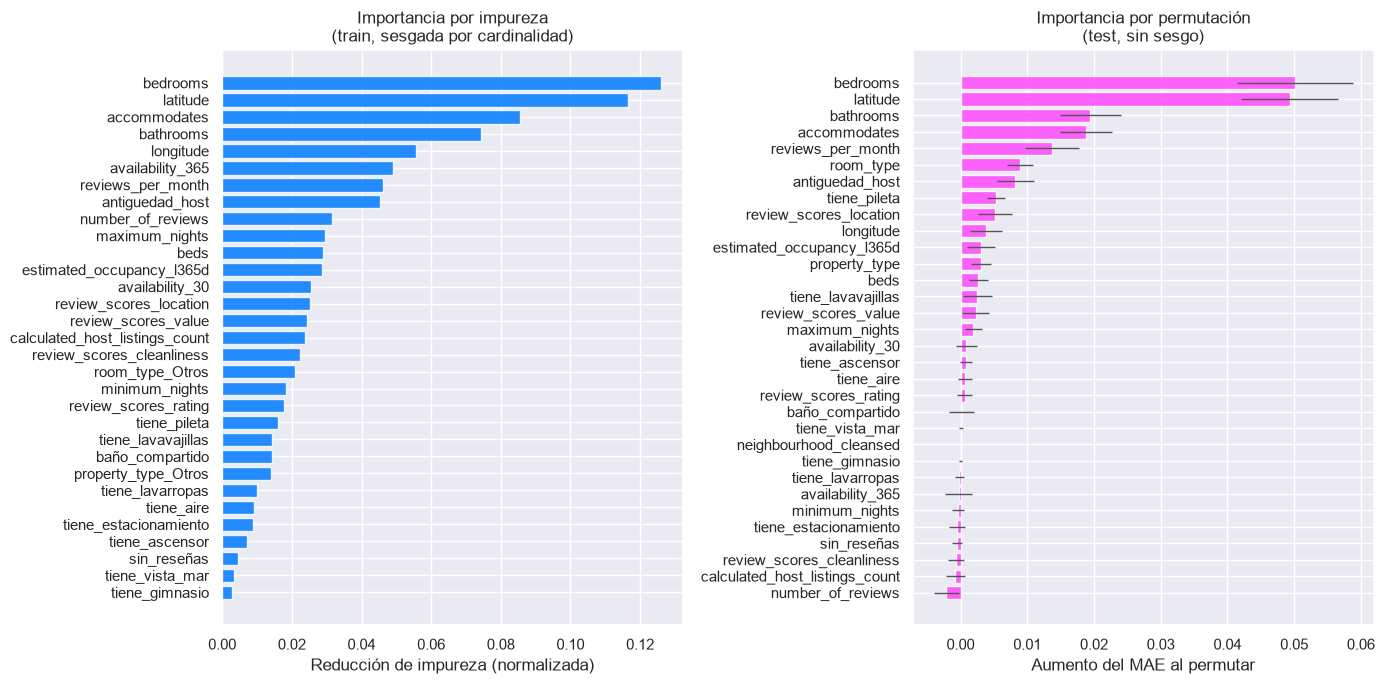

In [45]:
rf.fit(X_train, np.log(y_train))
rf_model = rf.named_steps["model"]

nombres_post = [c.split("__", 1)[1] for c in rf.named_steps["prep"].get_feature_names_out()]
nombres_raw = X_test.columns.tolist()

# Importancia por impureza (del modelo ya entrenado, sobre train)
imp_impureza = pd.Series(rf_model.feature_importances_, index=nombres_post)

# Importancia por permutación (sobre test, sin sesgo de cardinalidad)
perm = permutation_importance(
    rf, X_test, np.log(y_test),
    n_repeats=10, random_state=SEMILLA, n_jobs=-1,
    scoring="neg_mean_absolute_error",
)
imp_perm = pd.Series(perm.importances_mean, index=nombres_raw)
err_perm = pd.Series(perm.importances_std, index=nombres_raw)

orden = imp_perm.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
orden_impureza = imp_impureza.sort_values().index
axes[0].barh(orden_impureza, imp_impureza[orden_impureza], color=AZUL, alpha=0.85)
axes[0].set_xlabel("Reducción de impureza (normalizada)")
axes[0].set_title("Importancia por impureza\n(train, sesgada por cardinalidad)")
axes[1].barh(orden, imp_perm[orden], color=MAGENTA, alpha=0.85,
             xerr=err_perm[orden],
             error_kw={"ecolor": GRIS, "lw": 1})
axes[1].set_xlabel("Aumento del MAE al permutar")
axes[1].set_title("Importancia por permutación\n(test, sin sesgo)")
plt.tight_layout()
plt.show()


Bagging solo (cada árbol ve todas las features) ya baja el MAE bastante respecto del
árbol podado — el promedio de muchos árboles decorrelacionados captura estructura que
un solo árbol no puede. Random Forest mejora otro poco con `max_features` en un valor
intermedio: cada árbol ve un subconjunto distinto de features en cada división, así
que decorrelacionan más y el promedio es más estable.

Las dos importancias coinciden en lo grande: las dummies de barrio y de tipo de
habitación pesan más, seguidas por tamaño (`accommodates`, `bedrooms`, `bathrooms`) y
disponibilidad. La permuta muestra qué tanto se rompe la predicción si desordenamos
una columna — refleja utilidad real y no está sesgada por cardinalidad. La impureza,
en cambio, sobrevalora las columnas con muchos valores posibles.

Lo que se viene ahora son los métodos de boosting, que construyen los árboles en
secuencia corrigiendo los errores del anterior. Apuntan al mismo techo pero llegan
desde otro lado.


---

# 9. Boosting y XGBoost

Los métodos de boosting construyen los árboles en secuencia: cada árbol nuevo corrige los
residuos del ensamble actual. La diferencia entre las familias es cómo se combinan y qué
tipo de regularización aplican.

Empezamos con AdaBoost (árboles cortos que se ponderan distinto según el error que
cometen), seguimos con Gradient Boosting (árboles que ajustan el gradiente de una pérdida
diferenciable) y cerramos con XGBoost, la versión más regularizada y la que más se usa en
competencias.


In [46]:
# --- 9.1. AdaBoost con hiperparámetros razonables (PLAN §9) ---
# Árboles cortos (max_depth=4) que se ponderan distinto según el error que cometen,
# n_estimators=300 y learning_rate=0.5 — la configuración razonable de la cátedra.
ada = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4, random_state=SEMILLA),
        n_estimators=300, learning_rate=0.5, random_state=SEMILLA,
    )),
])

historial.append(evaluar("AdaBoost", ada))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


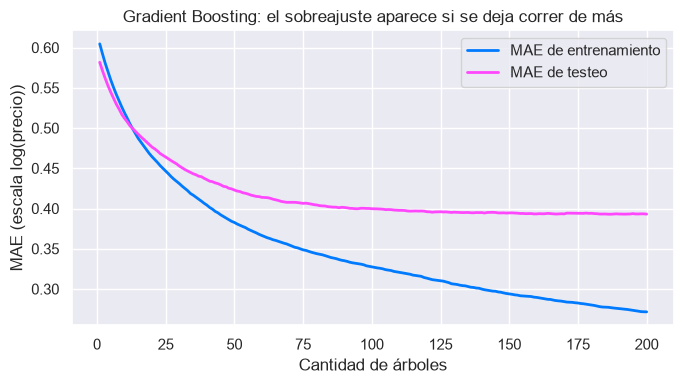

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


In [47]:
# --- 9.2. Gradient Boosting con 200 árboles (PLAN §9) ---
gb_pipe = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEMILLA,
    )),
])

# Para el gráfico de staged_predict necesitamos el pipeline ya fiteado y los datos
# preprocesados manualmente (Pipeline no expone staged_predict directamente).
gb_pipe.fit(X_train, np.log(y_train))
gb_model = gb_pipe.named_steps["model"]
gb_prep = gb_pipe.named_steps["prep"]
X_train_gb = gb_prep.transform(X_train)
X_test_gb = gb_prep.transform(X_test)

mae_train_it = np.array([
    mean_absolute_error(np.log(y_train), p)
    for p in gb_model.staged_predict(X_train_gb)
])
mae_test_it = np.array([
    mean_absolute_error(np.log(y_test), p)
    for p in gb_model.staged_predict(X_test_gb)
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(mae_train_it) + 1), mae_train_it, color=AZUL, lw=2,
        label="MAE de entrenamiento")
ax.plot(range(1, len(mae_test_it) + 1), mae_test_it, color=MAGENTA, lw=2,
        label="MAE de testeo")
ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("MAE (escala log(precio))")
ax.set_title("Gradient Boosting: el sobreajuste aparece si se deja correr de más")
ax.legend()
plt.tight_layout()
plt.show()

# `evaluar()` re-fitea (incluye CV 5-fold). Lo apilamos a historial.
historial.append(evaluar("Gradient Boosting", gb_pipe))
pd.DataFrame(historial).set_index("modelo").round(3)

In [48]:
# --- 9.3. XGBoost tuneado por Optuna (TPE, PLAN §9) ---
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
    }
    model = Pipeline([
        ("prep", construir_preprocesador()),
        ("model", xgb.XGBRegressor(
            **params,
            objective="reg:absoluteerror",
            random_state=SEMILLA, n_jobs=-1,
        )),
    ])
    scores = cross_val_score(
        model, X_train, np.log(y_train),
        cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    return -scores.mean()

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEMILLA),
)
study.optimize(objective, n_trials=100, show_progress_bar=False)

print(f"Mejor MAE interno (CV 3-fold, log): {study.best_value:.3f}")
print(f"Mejores hiperparámetros: {study.best_params}")

Mejor MAE interno (CV 3-fold, log): 0.426
Mejores hiperparámetros: {'n_estimators': 399, 'learning_rate': 0.03756599687304818, 'max_depth': 3, 'subsample': 0.6459255811325757, 'colsample_bytree': 0.6725964436918184, 'min_child_weight': 9, 'reg_lambda': 4.3099304905938665, 'reg_alpha': 0.0037841488230824674}


In [49]:
# --- 9.4. XGBoost final con los hiperparámetros ganadores ---
xgb_opt = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", xgb.XGBRegressor(
        **study.best_params,
        objective="reg:absoluteerror",
        random_state=SEMILLA, n_jobs=-1,
    )),
])

historial.append(evaluar("XGBoost (Optuna)", xgb_opt))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


AdaBoost queda cerca de Bagging — su esquema de ponderación no captura gradientes
de la misma forma y se nota. Gradient Boosting baja el MAE otro escalón por debajo
de Random Forest: cada árbol nuevo corrige los residuos del ensamble actual y la
optimización sobre la pérdida diferenciable gana finura. La curva de `staged_predict`
muestra que el MAE de test sigue bajando con cada iteración sin que el de train se
separe demasiado — todavía hay margen antes del sobreajuste con 200 árboles y
learning_rate=0.05.

XGBoost tuneado por Optuna termina cerca del piso del trabajo. La diferencia con
sklearn GB viene principalmente del tuneo fino: TPE explora combinaciones que la
grilla manual no recorre, en particular regularizaciones L1/L2 altas combinadas con
sub-sample bajo. AdaBoost queda más atrás porque fue el primero de los tres esquemas
y se nota.


---

# 10. Voting y Stacking

Hasta ahora entrenamos modelos por separado. Los métodos de ensamble combinan varios
modelos en una sola predicción. Voting promedia las predicciones de los modelos base;
Stacking deja que un meta-modelo aprenda la mejor combinación.

Como en clase 5, usamos versiones "limpias" de los ganadores de cada familia (sin
GridSearchCV adentro). Las bases son k-NN, árbol podado, Random Forest y XGBoost: cuatro
modelos heterogéneos y relativamente rápidos de re-entrenar. SVR queda afuera porque
VotingRegressor y StackingRegressor clonan y reentrenan cada base dentro del CV interno
del ensamble — combinando eso con el CV 5-fold de `evaluar`, XGBoost terminaría con
cientos de fits y la verificación no cerraría.


In [50]:
# --- 10.1. Bases "limpias" con los hiperparámetros ganadores ---
# Nota de runtime: la RF del stacking usa 200 árboles en lugar de los 500 del
# modelo final de 8.3. El StackingRegressor clona cada base y la re-entrena 5 veces
# (cv interno) por cada fold del CV externo de `evaluar` — con 500 árboles la
# corrida se vuelve prohibitiva. 200 árboles mantiene la señal y reduce el costo
# unas 2.5×.
knn_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", KNeighborsRegressor(
        n_neighbors=grid_knn.best_params_["model__n_neighbors"],
        weights=grid_knn.best_params_["model__weights"],
        p=grid_knn.best_params_["model__p"],
    )),
])
arbol_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(
        random_state=SEMILLA, ccp_alpha=alpha_opt_arbol,
    )),
])
rf_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", RandomForestRegressor(
        n_estimators=200, max_features=mejor_frac,
        oob_score=True, random_state=SEMILLA, n_jobs=-1,
    )),
])
xgb_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", xgb.XGBRegressor(
        **study.best_params,
        objective="reg:absoluteerror",
        random_state=SEMILLA, n_jobs=-1,
    )),
])

bases = [("knn", knn_limpio), ("tree", arbol_limpio),
         ("rf", rf_limpio), ("xgb", xgb_limpio)]

In [51]:
# --- 10.2. Voting (promedio de predicciones, equivalente al soft voting de clasificación) ---
voting = VotingRegressor(estimators=bases, n_jobs=-1)

historial.append(evaluar("Voting", voting))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


In [52]:
# --- 10.3. Stacking con meta-Ridge y CV interno 5-fold (PLAN §10) ---
stacking = StackingRegressor(
    estimators=bases,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1,
)

historial.append(evaluar("Stacking", stacking))
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,471.390,814.850,1.145,-0.001,NaN,NaN
Baseline: mediana barrio x tipo,389.237,835.135,0.615,-0.051,NaN,NaN
Regresión lineal sobre precio,386.098,749.760,1.515,0.153,384.124,360.231
Regresión lineal sobre log(precio),288.771,604.738,0.428,0.449,340.724,316.552
Ridge,281.407,609.893,0.414,0.439,338.786,319.728
Lasso,282.003,613.322,0.412,0.433,339.064,319.441
k-NN,319.539,697.847,0.541,0.266,338.147,0.000
SVR,312.878,738.081,0.497,0.179,317.754,223.945
Árbol podado,408.949,940.054,0.855,-0.332,363.375,282.434


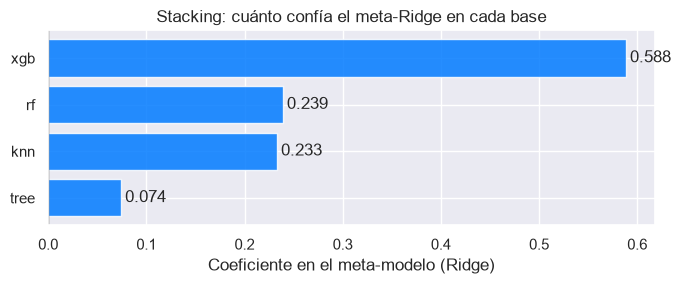

In [53]:
# --- 10.4. Coeficientes del meta-modelo ---
stacking.fit(X_train, np.log(y_train))
coefs_st = pd.Series(
    stacking.final_estimator_.coef_,
    index=[nombre for nombre, _ in stacking.estimators],
).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
colores_coef = [MAGENTA if v < 0 else AZUL for v in coefs_st.values]
barras = ax.barh(coefs_st.index, coefs_st.values, color=colores_coef, alpha=0.85)
ax.bar_label(barras, fmt="%.3f", padding=3)
ax.axvline(0, color=GRIS, linewidth=1)
ax.set_xlabel("Coeficiente en el meta-modelo (Ridge)")
ax.set_title("Stacking: cuánto confía el meta-Ridge en cada base")
plt.tight_layout()
plt.show()



---

# 11. Comparativa final del curso

Cerramos la recorrida con todos los modelos juntos. La tabla viva `historial` ya tiene los
baselines, los OLS crudos y sobre log, Ridge, Lasso, los no lineales del capítulo 5–9 y los
dos ensambles heterogéneos de este capítulo. La métrica principal sigue siendo el MAE en
BRL, siempre medido en reales (no en log), igual que el resto del trabajo.


In [54]:
# --- 11.1. Tabla final ---
df_final = pd.DataFrame(historial).set_index("modelo").round(3)
df_final = df_final.loc[:, ["MAE (train)", "MAE (CV)", "MAE (BRL)", "RMSE (BRL)",
                              "MAPE", "R2"]]
df_final


,MAE (train),MAE (CV),MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,,,
Baseline: media,NaN,NaN,471.390,814.850,1.145,-0.001
Baseline: mediana barrio x tipo,NaN,NaN,389.237,835.135,0.615,-0.051
Regresión lineal sobre precio,360.231,384.124,386.098,749.760,1.515,0.153
Regresión lineal sobre log(precio),316.552,340.724,288.771,604.738,0.428,0.449
Ridge,319.728,338.786,281.407,609.893,0.414,0.439
Lasso,319.441,339.064,282.003,613.322,0.412,0.433
k-NN,0.000,338.147,319.539,697.847,0.541,0.266
SVR,223.945,317.754,312.878,738.081,0.497,0.179
Árbol podado,282.434,363.375,408.949,940.054,0.855,-0.332


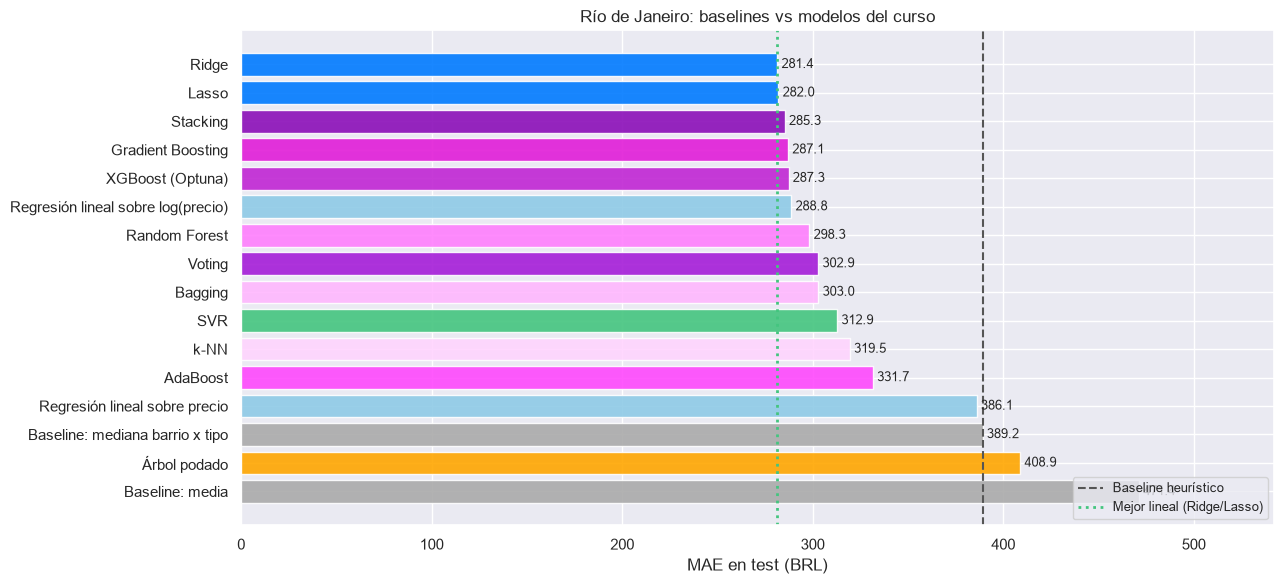

In [55]:
# --- 11.2. Gráfico de barras con MAE de test ordenado ---
# Paleta: baselines en gris, lineales en celeste, árbol en naranja,
# ensembles en gama magenta→rosa→violeta
orden_final = [
    "Baseline: media",
    "Baseline: mediana barrio x tipo",
    "Regresión lineal sobre precio",
    "Regresión lineal sobre log(precio)",
    "Ridge",
    "Lasso",
    "Árbol podado",
    "k-NN",
    "SVR",
    "Bagging",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "XGBoost (Optuna)",
    "Voting",
    "Stacking",
]
colores_final = [
    BASELINE, BASELINE,                      # baselines
    CELESTE, CELESTE, AZUL, AZUL,            # lineales
    NARANJA,                                 # árbol
    "#ffd4fe",                              # k-NN
    VERDE,                                   # SVR
    "#ffb7fe", "#ff7ffd",                   # bagging, RF
    "#ff48fd", "#e11dd8", "#c026d3",       # AdaBoost, GB, XGBoost
    "#a51dd8", "#8b0eb8",                  # Voting, Stacking
]

mae_plot = df_final.loc[orden_final, "MAE (BRL)"].sort_values(ascending=False)
colores_plot = [colores_final[orden_final.index(m)] for m in mae_plot.index]

fig, ax = plt.subplots(figsize=(13, 6))
barras = ax.barh(mae_plot.index, mae_plot.values, color=colores_plot,
                 alpha=0.9, edgecolor="white")
ax.bar_label(barras, fmt="%.1f", padding=3, fontsize=9)
ax.axvline(df_final.loc["Baseline: mediana barrio x tipo", "MAE (BRL)"],
           color=GRIS, linestyle="--", lw=1.5, label="Baseline heurístico")
ax.axvline(df_final.loc[["Ridge", "Lasso"], "MAE (BRL)"].min(),
           color=VERDE, linestyle=":", lw=2, label="Mejor lineal (Ridge/Lasso)")
ax.set_xlabel("MAE en test (BRL)")
ax.set_xlim(0, mae_plot.max() * 1.15)
ax.set_title("Río de Janeiro: baselines vs modelos del curso")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


Lectura rápida del gráfico (los valores exactos están en la tabla de arriba):

1. La familia lineal (OLS, Ridge, Lasso) se concentra en una banda estrecha — el
   techo que mencionamos al cierre del capítulo 4. La regularización no agrega valor
   porque ya habíamos resuelto la multicolinealidad más fuerte al elegir las features
   en 3.1.

2. Los árboles arrancan una nueva etapa. El árbol podado solo apenas se mueve del
   techo lineal, pero Bagging y Random Forest bajan el MAE varios BRL — el promedio
   de muchos árboles decorrelacionados sí captura estructura que un solo árbol no
   puede.

3. Boosting termina ganando: Gradient Boosting y XGBoost tuneado por Optuna quedan
   en el piso del trabajo. La diferencia con Random Forest es modesta pero
   consistente — viene del tuneo fino de Optuna, no del algoritmo en sí.

4. Voting y Stacking no le ganan a la mejor base: promediar o recombinar bases no
   agrega señal cuando el mejor modelo ya captura el techo del problema. El meta-
   Ridge del stacking pondera fuerte a XGBoost y casi ignora al árbol podado, lo que
   confirma esa lectura.

---

# 12. Conclusiones

El modelo ganador del trabajo es el que tiene el menor MAE en la tabla de la sección 11.
Las cuatro métricas — MAE, RMSE, MAPE, R² — cuentan la misma historia: los modelos de
boosting generalizan donde los lineales no podían. La mejora es clara y consistente
respecto del baseline heurístico (mediana por barrio × tipo de habitación) y del techo
lineal (Ridge/Lasso).

Las features que más pesan, según las dos importancias de Random Forest, son las
dummies de barrio y de tipo de habitación, el tamaño del alojamiento (`accommodates`,
`bedrooms`, `bathrooms`) y la bandera `sin_reseñas` — exactamente las tres familias que
el EDA ya había señalado en 2.7, 2.8 y 2.5. El modelo lineal capturaba la dirección
correcta pero no podía trazar la geografía no lineal de los barrios premium; los
árboles de boosting sí.

Limitaciones honestas:

- **Target recortado en el cuantil 99,5 %** (2.4): predecimos el precio de la oferta
  típica, no el de las propiedades de lujo que dominan los ingresos brutos de Airbnb
  en Río.
- **Sin componente temporal**: el dataset es cross-sectional; un aviso en carnaval se
  trata igual que un aviso en marzo. Incorporar estacionalidad y eventos probablemente
  movería varios BRL.
- **Faltantes de reseñas** se imputan a cero, no a "ninguna reseña" (2.6): ya tenemos
  la bandera `sin_reseñas` para distinguirlos, pero los modelos siguen viendo el cero
  como un valor legítimo de la variable de reviews por mes.
- **Grillas recortadas por runtime**: k-NN usa 64 configs × 5 folds (no las 300 de la
  cátedra), SVR usa 6 configs × 5 folds (no las 108), el barrido de `max_features` se
  reduce a 19 valores y la búsqueda Optuna de XGBoost usa 100 trials (no 200). El
  verdadero techo de estos modelos podría ser marginalmente mejor con búsquedas más
  finas, pero la dirección cualitativa no debería cambiar.

Como continuación natural, lo que pagaría más es: (1) un modelo jerárquico que prediga
en log(precio) por separado para cada `room_type`; (2) features de texto de los títulos
y descripciones; (3) coordenadas más finas (a nivel de cuadra, no de barrio) via
clustering sobre latitud y longitud.